# 06 International Football Elo + Polymarket Odds

Collect World Football Elo data and Polymarket World Cup moneyline prices into one match-level table.

Sources:

- World Football Elo Ratings: https://eloratings.net/
- World Football Elo latest/results page: https://eloratings.net/latest
- Polymarket Gamma/Data APIs

Goal table, one row per match:

- Match metadata: date, event slug, home team, away team.
- Polymarket pre-match implied prices for home win, draw, and away win.
- Elo ratings for both teams immediately before the match.
- Elo-estimated W/D/L probabilities.

The notebook caches raw downloads under `data/cache/football_elo_polymarket/` so repeated runs do not keep hitting external APIs. Polymarket event metadata is stored in one compact JSON file with moneyline fields only. Pre-match price windows are stored as compact averages in `polymarket_price_history_aggregates.json` (not full tick history).

Derived tables (match table, knockout bracket, backtests, exports for the HTML page) are recomputed every run and written to `docs/data/football_elo_polymarket/` when `EXPORT_DERIVED_FOR_HTML = True`. They are never read back from disk.

In [1]:
from __future__ import annotations

import json
import os
import math
import re
import time
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
from difflib import get_close_matches

NOTEBOOK_OR_REPO_ROOT = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_OR_REPO_ROOT.parent if NOTEBOOK_OR_REPO_ROOT.name == "notebooks" else NOTEBOOK_OR_REPO_ROOT
CACHE_DIR = REPO_ROOT / "data" / "cache" / "football_elo_polymarket"
EXPORT_DIR = REPO_ROOT / "docs" / "data" / "football_elo_polymarket"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ELO_BASE_URL = "https://eloratings.net"
POLYMARKET_GAMMA_URL = "https://gamma-api.polymarket.com"
POLYMARKET_CLOB_URL = "https://clob.polymarket.com"

WORLD_CUP_SERIES_SLUG = "soccer-fifwc"
WORLD_CUP_TOURNAMENT_CODE = "WC"
WORLD_CUP_YEAR = 2026

REQUEST_SLEEP_SECONDS = 0.15
VERBOSE = True

# Refresh Elo each run; override with ELO_FORCE_REFRESH=0 to use cache only.
ELO_FORCE_REFRESH = os.getenv("ELO_FORCE_REFRESH", "true").strip().lower() in {"1", "true", "yes"}

# Refresh Polymarket event metadata each run; completed price-history windows still cache by default.
POLYMARKET_FORCE_REFRESH = False
POLYMARKET_EVENTS_FORCE_REFRESH = False

# Derived tables are recomputed in-memory each run. Write fresh CSV exports for the HTML page only.
EXPORT_DERIVED_FOR_HTML = True

# Average CLOB price-history points during this window before kickoff/current time.
PRE_MATCH_PRICE_WINDOW_HOURS = 6
PRICE_HISTORY_FIDELITY_MINUTES = 1
PRICE_HISTORY_AGGREGATES_NAME = "polymarket_price_history_aggregates.json"
POLYMARKET_EVENTS_CACHE_NAME = f"polymarket_events_{WORLD_CUP_SERIES_SLUG}_compact.json"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [2]:
def cache_path(name: str) -> Path:
    return CACHE_DIR / name


def export_path(name: str) -> Path:
    return EXPORT_DIR / name


def export_derived_table(df: pd.DataFrame, name: str) -> Path | None:
    if not EXPORT_DERIVED_FOR_HTML:
        return None
    path = export_path(name)
    df.to_csv(path, index=False)
    log_progress(f"[export] {path}")
    touch_export_timestamp()
    return path


def touch_export_timestamp() -> None:
    if not EXPORT_DERIVED_FOR_HTML:
        return
    timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    export_path("last_updated.txt").write_text(timestamp, encoding="utf-8")


def log_progress(message: str) -> None:
    if VERBOSE:
        print(message, flush=True)


def fetch_elo_text(url: str, *, params: dict[str, Any] | None = None) -> str:
    """Download raw TSV/text from eloratings.net using browser-like XHR requests."""
    import urllib.error
    import urllib.request
    from urllib.parse import parse_qs, urlencode, urlparse, urlunparse

    request_params = dict(params or {})
    request_params.setdefault("_", str(int(time.time() * 1000)))

    browser_headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"
        ),
        "Accept": "text/tab-separated-values,text/plain,*/*",
        "Referer": "https://eloratings.net/",
        "Accept-Language": "en-US,en;q=0.9",
    }

    candidate_urls = [url]
    if "://eloratings.net/" in url:
        candidate_urls.append(url.replace("://eloratings.net/", "://www.eloratings.net/"))

    last_error: Exception | None = None
    for attempt in range(1, 4):
        for candidate_url in candidate_urls:
            try:
                response = requests.get(
                    candidate_url,
                    params=request_params,
                    headers=browser_headers,
                    timeout=60,
                )
                response.raise_for_status()
                return response.text
            except requests.RequestException as exc:
                last_error = exc
                status = getattr(getattr(exc, "response", None), "status_code", None)
                log_progress(
                    f"[download] attempt {attempt}/3 requests failed "
                    f"({candidate_url}, status={status})"
                )

            try:
                parsed = urlparse(candidate_url)
                query = parse_qs(parsed.query)
                for key, value in request_params.items():
                    query[str(key)] = [str(value)]
                full_url = urlunparse(parsed._replace(query=urlencode(query, doseq=True)))
                request = urllib.request.Request(full_url, headers=browser_headers, method="GET")
                with urllib.request.urlopen(request, timeout=60) as resp:
                    charset = resp.headers.get_content_charset() or "utf-8"
                    return resp.read().decode(charset)
            except (urllib.error.URLError, TimeoutError, ValueError) as exc:
                last_error = exc
                log_progress(f"[download] attempt {attempt}/3 urllib failed ({candidate_url}): {exc}")

        if attempt < 3:
            time.sleep(REQUEST_SLEEP_SECONDS * attempt * 4)

    assert last_error is not None
    raise last_error


def _is_valid_elo_cache_text(text: str, cache_name: str) -> bool:
    if not text or not text.strip():
        return False
    if cache_name.endswith(".tsv"):
        return any(line.strip() and "\t" in line for line in text.splitlines())
    return True


def _read_elo_cache_fallback(path: Path, cache_name: str, reason: str) -> str | None:
    if not path.exists():
        return None
    cached = path.read_text(encoding="utf-8")
    if _is_valid_elo_cache_text(cached, cache_name):
        log_progress(f"[cache] {reason}; using cached {cache_name}")
        return cached
    return None


def get_text_cached(url: str, cache_name: str, *, force_refresh: bool = False, params: dict[str, Any] | None = None) -> str:
    path = cache_path(cache_name)
    if path.exists() and not force_refresh:
        log_progress(f"[cache] {cache_name}")
        return path.read_text(encoding="utf-8")

    log_progress(f"[download] {url} -> {cache_name}")
    try:
        text = fetch_elo_text(url, params=params)
    except Exception as exc:
        fallback = _read_elo_cache_fallback(path, cache_name, f"download failed ({exc})")
        if fallback is not None:
            return fallback
        raise

    if not _is_valid_elo_cache_text(text, cache_name):
        fallback = _read_elo_cache_fallback(path, cache_name, f"invalid download from {url}")
        if fallback is not None:
            return fallback
        raise RuntimeError(f"Invalid Elo download for {url} (-> {cache_name})")

    path.write_text(text, encoding="utf-8")
    time.sleep(REQUEST_SLEEP_SECONDS)
    return text


LEGACY_POLYMARKET_EVENT_PAGE_PATTERN = re.compile(
    rf"^polymarket_events_{re.escape(WORLD_CUP_SERIES_SLUG)}_\d+_\d+\.json$"
)


def assert_not_legacy_polymarket_event_cache(cache_name: str) -> None:
    if LEGACY_POLYMARKET_EVENT_PAGE_PATTERN.match(cache_name):
        legacy_path = cache_path(cache_name)
        if legacy_path.exists():
            legacy_path.unlink(missing_ok=True)
            log_progress(f"[cache] blocked and removed legacy {cache_name}")
        raise RuntimeError(
            "Paginated Polymarket event cache files are disabled. "
            "Restart the kernel, re-run all cells, and use wc_polymarket_cache.load_world_cup_events(). "
            f"Only {POLYMARKET_EVENTS_CACHE_NAME} should exist on disk."
        )


def fetch_knockout_more_markets(*args: str) -> dict[str, Any]:
    """Accept either (event_slug, team1, team2) or (gamma_url, event_slug, team1, team2)."""
    importlib.reload(_wc_polymarket_cache)
    if len(args) == 3:
        event_slug, team1, team2 = args
        gamma_url = POLYMARKET_GAMMA_URL
    elif len(args) == 4:
        gamma_url, event_slug, team1, team2 = args
    else:
        raise TypeError(
            "fetch_knockout_more_markets expected 3 or 4 positional arguments, "
            f"got {len(args)}"
        )
    return _wc_polymarket_cache.fetch_knockout_more_markets(
        gamma_url,
        event_slug,
        team1,
        team2,
    )


def fetch_penalty_score_from_skysports(
    team1: str,
    team2: str,
    team1_goals: int,
    team2_goals: int,
) -> tuple[int | None, int | None]:
    importlib.reload(_wc_polymarket_cache)
    return _wc_polymarket_cache.fetch_penalty_score_from_skysports(
        team1,
        team2,
        team1_goals,
        team2_goals,
    )


def get_json_cached(url: str, cache_name: str, *, force_refresh: bool = False, params: dict[str, Any] | None = None) -> Any:
    assert_not_legacy_polymarket_event_cache(cache_name)
    path = cache_path(cache_name)
    if path.exists() and not force_refresh:
        log_progress(f"[cache] {cache_name}")
        return json.loads(path.read_text(encoding="utf-8"))

    log_progress(f"[download] {url} {params or {}} -> {cache_name}")
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    time.sleep(REQUEST_SLEEP_SECONDS)
    return data


def load_price_history_aggregates() -> dict[str, Any]:
    path = cache_path(PRICE_HISTORY_AGGREGATES_NAME)
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def save_price_history_aggregates(aggregates: dict[str, Any]) -> None:
    path = cache_path(PRICE_HISTORY_AGGREGATES_NAME)
    path.write_text(json.dumps(aggregates, indent=2, sort_keys=True), encoding="utf-8")


def price_history_aggregate_key(token_id: str, *, end_ts: int, is_final: bool) -> str:
    fidelity = PRICE_HISTORY_FIDELITY_MINUTES
    if is_final:
        return f"final|{token_id}|{end_ts}|f{fidelity}"
    return f"live|{token_id}|f{fidelity}"


def migrate_legacy_price_history_cache() -> None:
    """One-time migration from per-window JSON files to compact aggregate cache."""
    pattern = re.compile(r"^polymarket_price_history_(.+)_([0-9]+)_([0-9]+)_f([0-9]+)$")
    aggregates = load_price_history_aggregates()
    migrated = 0
    now_ts = int(pd.Timestamp.now(tz="UTC").timestamp())

    for legacy_path in list(CACHE_DIR.glob("polymarket_price_history_*.json")):
        if legacy_path.name == PRICE_HISTORY_AGGREGATES_NAME:
            continue
        match = pattern.match(legacy_path.stem)
        if not match:
            continue

        token_id = match.group(1)
        start_ts = int(match.group(2))
        end_ts = int(match.group(3))
        is_final = end_ts <= now_ts
        cache_key = price_history_aggregate_key(token_id, end_ts=end_ts, is_final=is_final)

        data = json.loads(legacy_path.read_text(encoding="utf-8"))
        history = data.get("history", data if isinstance(data, list) else [])
        prices = pd.to_numeric(pd.Series([point.get("p") for point in history]), errors="coerce")
        average_price = float(prices.mean()) if prices.notna().any() else np.nan
        point_count = int(prices.notna().sum())

        if cache_key not in aggregates:
            aggregates[cache_key] = {
                "average_price": average_price,
                "point_count": point_count,
                "start_ts": start_ts,
                "end_ts": end_ts,
                "is_final": is_final,
                "cached_at": datetime.now(timezone.utc).isoformat(),
            }
            migrated += 1

        legacy_path.unlink()

    if migrated:
        save_price_history_aggregates(aggregates)
        log_progress(
            f"[cache] migrated {migrated} legacy price-history file(s) into {PRICE_HISTORY_AGGREGATES_NAME}"
        )


migrate_legacy_price_history_cache()


import importlib
import sys as _sys

_WC_NOTEBOOK_DIR = Path.cwd()
if str(_WC_NOTEBOOK_DIR) not in _sys.path:
    _sys.path.insert(0, str(_WC_NOTEBOOK_DIR))
import wc_polymarket_cache as _wc_polymarket_cache
importlib.reload(_wc_polymarket_cache)


def _polymarket_cache_log(message: str) -> None:
    if VERBOSE:
        log_progress(message)


def cleanup_legacy_polymarket_event_caches() -> None:
    _wc_polymarket_cache.cleanup_legacy_paginated_event_caches(
        CACHE_DIR,
        WORLD_CUP_SERIES_SLUG,
        POLYMARKET_EVENTS_CACHE_NAME,
        log=_polymarket_cache_log,
    )


def migrate_legacy_polymarket_event_caches() -> None:
    _wc_polymarket_cache.migrate_legacy_paginated_event_caches(
        CACHE_DIR,
        WORLD_CUP_SERIES_SLUG,
        POLYMARKET_EVENTS_CACHE_NAME,
        log=_polymarket_cache_log,
    )


def load_polymarket_world_cup_events(page_size: int = 100) -> list[dict[str, Any]]:
    importlib.reload(_wc_polymarket_cache)
    return _wc_polymarket_cache.load_world_cup_events(
        cache_dir=CACHE_DIR,
        gamma_url=POLYMARKET_GAMMA_URL,
        series_slug=WORLD_CUP_SERIES_SLUG,
        compact_cache_name=POLYMARKET_EVENTS_CACHE_NAME,
        force_refresh=POLYMARKET_EVENTS_FORCE_REFRESH,
        page_size=page_size,
        sleep_seconds=REQUEST_SLEEP_SECONDS,
        log=_polymarket_cache_log,
    )


migrate_legacy_polymarket_event_caches()
cleanup_legacy_polymarket_event_caches()




def parse_jsonish_list(value: Any) -> list[Any]:
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except json.JSONDecodeError:
            return []
    return []


def parse_int(value: Any) -> int | None:
    if value is None:
        return None
    text = str(value).strip().replace("−", "-").replace("â", "-")
    if text in {"", "-", "–"}:
        return None
    return int(text)


def parse_float(value: Any) -> float | None:
    if value is None:
        return None
    text = str(value).strip().replace("−", "-").replace("â", "-")
    if text in {"", "-", "–"}:
        return None
    return float(text)


def iso_to_unix_seconds(value: str | None) -> int | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    timestamp = pd.to_datetime(value, errors="coerce", utc=True)
    if pd.isna(timestamp):
        return None
    return int(timestamp.timestamp())

## World Football Elo Raw Data

`eloratings.net` renders via JavaScript, but it loads raw TSV files such as:

- `en.teams.tsv` for team-code lookup.
- `teams.tsv` for historical successor/alias codes.
- `2026_results.tsv` for match results and rating changes.
- `fixtures.tsv` for upcoming matches and current pre-match ratings.

For completed results, the TSV row stores post-match ratings plus the rating change for the first-listed team. To recover the ratings immediately before the match:

- `pre_team1_elo = post_team1_elo - rating_change`
- `pre_team2_elo = post_team2_elo + rating_change`

This assumes the Elo update is approximately zero-sum between the two teams, which matches the published row format.

In [3]:
def load_elo_team_tables() -> tuple[pd.DataFrame, dict[str, str], dict[str, str]]:
    teams_text = get_text_cached(f"{ELO_BASE_URL}/en.teams.tsv", "elo_en_teams.tsv", force_refresh=ELO_FORCE_REFRESH)
    successor_text = get_text_cached(f"{ELO_BASE_URL}/teams.tsv", "elo_successor_teams.tsv", force_refresh=ELO_FORCE_REFRESH)

    team_rows = []
    for line in teams_text.splitlines():
        fields = line.split("\t")
        if len(fields) < 2:
            continue
        code, names = fields[0], fields[1:]
        team_rows.append({"code": code, "primary_name": names[0], "all_names": names})

    teams = pd.DataFrame(team_rows)
    code_to_name = dict(zip(teams["code"], teams["primary_name"]))

    successor = {}
    for line in successor_text.splitlines():
        fields = line.split("\t")
        if len(fields) >= 2:
            successor[fields[0]] = fields[1]

    return teams, code_to_name, successor


elo_teams, elo_code_to_name, elo_successor = load_elo_team_tables()
elo_teams.head()

[download] https://eloratings.net/en.teams.tsv -> elo_en_teams.tsv
[download] https://eloratings.net/teams.tsv -> elo_successor_teams.tsv


,code,primary_name,all_names
0,DN,Aden,[Aden]
1,AF,Afghanistan,[Afghanistan]
2,AL,Albania,[Albania]
3,DZ,Algeria,[Algeria]
4,AD,Andorra,[Andorra]


In [4]:
def resolve_elo_code(code: str) -> str:
    return elo_successor.get(code, code)


def parse_elo_date(fields: list[str]) -> pd.Timestamp | None:
    date = pd.to_datetime(
        f"{fields[0]}-{fields[1]}-{fields[2]}",
        errors="coerce",
        utc=True,
    )
    if pd.isna(date):
        return None
    return date.normalize()


def parse_elo_results(year: int = WORLD_CUP_YEAR) -> pd.DataFrame:
    text = get_text_cached(f"{ELO_BASE_URL}/{year}_results.tsv", f"elo_{year}_results.tsv", force_refresh=ELO_FORCE_REFRESH)
    rows = []
    for line in text.splitlines():
        fields = line.split("\t")
        if len(fields) < 16:
            continue

        date = parse_elo_date(fields)
        if date is None:
            continue

        team1_code = resolve_elo_code(fields[3])
        team2_code = resolve_elo_code(fields[4])
        rating_change = parse_int(fields[9])
        team1_elo_after = parse_int(fields[10])
        team2_elo_after = parse_int(fields[11])

        rows.append(
            {
                "date": date,
                "team1_code": team1_code,
                "team2_code": team2_code,
                "team1": elo_code_to_name.get(team1_code, team1_code),
                "team2": elo_code_to_name.get(team2_code, team2_code),
                "team1_goals": parse_int(fields[5]),
                "team2_goals": parse_int(fields[6]),
                "tournament_code": fields[7],
                "venue_code": fields[8],
                "rating_change_team1": rating_change,
                "team1_elo_after": team1_elo_after,
                "team2_elo_after": team2_elo_after,
                "team1_elo_pre": None if team1_elo_after is None or rating_change is None else team1_elo_after - rating_change,
                "team2_elo_pre": None if team2_elo_after is None or rating_change is None else team2_elo_after + rating_change,
                "source": f"{year}_results.tsv",
            }
        )

    return pd.DataFrame(rows)


def parse_elo_fixtures() -> pd.DataFrame:
    text = get_text_cached(f"{ELO_BASE_URL}/fixtures.tsv", "elo_fixtures.tsv", force_refresh=ELO_FORCE_REFRESH)
    rows = []
    for line in text.splitlines():
        fields = line.split("\t")
        if len(fields) < 12:
            continue

        date = parse_elo_date(fields)
        if date is None:
            continue

        team1_code = resolve_elo_code(fields[3])
        team2_code = resolve_elo_code(fields[4])
        rows.append(
            {
                "date": date,
                "team1_code": team1_code,
                "team2_code": team2_code,
                "team1": elo_code_to_name.get(team1_code, team1_code),
                "team2": elo_code_to_name.get(team2_code, team2_code),
                "team1_goals": None,
                "team2_goals": None,
                "tournament_code": fields[5],
                "venue_code": fields[6],
                "rating_change_team1": None,
                "team1_elo_after": None,
                "team2_elo_after": None,
                "team1_elo_pre": parse_int(fields[9]),
                "team2_elo_pre": parse_int(fields[10]),
                "elo_site_winexp_team1_pct": parse_float(fields[11]),
                "source": "fixtures.tsv",
            }
        )

    return pd.DataFrame(rows)


elo_results = parse_elo_results(WORLD_CUP_YEAR)
elo_fixtures = parse_elo_fixtures()

elo_world_cup_matches = pd.concat(
    [
        elo_results.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE"),
        elo_fixtures.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE"),
    ],
    ignore_index=True,
).sort_values(["date", "team1", "team2"])

elo_world_cup_matches.head()

[download] https://eloratings.net/2026_results.tsv -> elo_2026_results.tsv
[download] https://eloratings.net/fixtures.tsv -> elo_fixtures.tsv


,date,team1_code,team2_code,team1,team2,team1_goals,team2_goals,tournament_code,venue_code,rating_change_team1,team1_elo_after,team2_elo_after,team1_elo_pre,team2_elo_pre,source,elo_site_winexp_team1_pct
1,2026-06-11 00:00:00+00:00,MX,ZA,Mexico,South Africa,2,0,WC,,6,1881,1511,1875,1517,2026_results.tsv,NaN
0,2026-06-11 00:00:00+00:00,KR,CZ,South Korea,Czechia,2,1,WC,MX,28,1786,1712,1758,1740,2026_results.tsv,NaN
3,2026-06-12 00:00:00+00:00,CA,BA,Canada,Bosnia and Herzegovina,1,1,WC,,-21,1767,1616,1788,1595,2026_results.tsv,NaN
2,2026-06-12 00:00:00+00:00,US,PY,United States,Paraguay,4,1,WC,,54,1780,1780,1726,1834,2026_results.tsv,NaN
7,2026-06-13 00:00:00+00:00,AU,TR,Australia,Turkey,2,0,WC,CA,62,1839,1849,1777,1911,2026_results.tsv,NaN


## Elo W/D/L Probability Model

Standard Elo gives an expected score, not directly W/D/L:

`E_home = P(home win) + 0.5 * P(draw)`

To split this into win/draw/loss, this notebook uses the Bradley-Terry-Davidson draw model:

- `strength_home = 10 ** ((elo_home + home_advantage) / 400)`
- `strength_away = 10 ** (elo_away / 400)`
- `draw_strength = nu * sqrt(strength_home * strength_away)`
- denominator = `strength_home + strength_away + draw_strength`

Then:

- `P(home win) = strength_home / denominator`
- `P(draw) = draw_strength / denominator`
- `P(away win) = strength_away / denominator`

`nu` controls draw frequency. Instead of setting `nu` directly, we set the expected draw probability when teams are evenly matched. The default here is `26%`, which implies `nu = 2 * draw_rate / (1 - draw_rate)`.

Set `HOME_ADVANTAGE_ELO = 0` for neutral-site World Cup games. You can raise it for true home advantage or co-host advantage.

In [5]:
BASE_DRAW_PROBABILITY_EQUAL_TEAMS = 0.28
HOME_ADVANTAGE_ELO = 0.0


def davidson_draw_parameter(draw_probability_equal_teams: float) -> float:
    if not 0 < draw_probability_equal_teams < 1:
        raise ValueError("draw_probability_equal_teams must be between 0 and 1.")
    return 2 * draw_probability_equal_teams / (1 - draw_probability_equal_teams)


def elo_wdl_probabilities(
    team1_elo: float,
    team2_elo: float,
    *,
    home_advantage_elo: float = HOME_ADVANTAGE_ELO,
    draw_probability_equal_teams: float = BASE_DRAW_PROBABILITY_EQUAL_TEAMS,
) -> tuple[float, float, float]:
    """Return Davidson-model P(team1 win), P(draw), P(team2 win)."""
    nu = davidson_draw_parameter(draw_probability_equal_teams)
    strength1 = 10 ** ((team1_elo + home_advantage_elo) / 400)
    strength2 = 10 ** (team2_elo / 400)
    draw_strength = nu * math.sqrt(strength1 * strength2)
    denom = strength1 + strength2 + draw_strength
    return strength1 / denom, draw_strength / denom, strength2 / denom


example_probs = elo_wdl_probabilities(1800, 1700)
pd.Series(
    {
        "example_team1_win": example_probs[0],
        "example_draw": example_probs[1],
        "example_team2_win": example_probs[2],
        "sum": sum(example_probs),
    }
)

example_team1_win    0.466072
example_draw         0.271837
example_team2_win    0.262091
sum                  1.000000
dtype: float64

## Polymarket World Cup Moneyline Data

The Gamma API can return FIFA World Cup events with `series_slug=soccer-fifwc`. Each event contains nested markets. For moneyline W/D/L odds, we keep markets where `sportsMarketType == "moneyline"`.

For each binary outcome market, the notebook estimates the YES price from CLOB `prices-history`:

- Fetch YES token price history over the configured window.
- Fetch NO token price history over the same window.
- Use the average of `YES price` and `1 - NO price` when both are available.

For completed matches, the window ends at kickoff. For upcoming matches, the window ends at current time.

In [6]:
def event_start_timestamp(event: dict[str, Any]):
    return pd.to_datetime(event.get("startTime") or event.get("endDate"), errors="coerce", utc=True)


def event_is_final(event: dict[str, Any], now: pd.Timestamp | None = None) -> bool:
    if event.get("closed") or event.get("ended") or event.get("finishedTimestamp"):
        return True
    start = event_start_timestamp(event)
    if pd.isna(start):
        return False
    now = pd.Timestamp.now(tz="UTC") if now is None else now
    return start <= now


def event_match_date(event: dict[str, Any]):
    event_date = pd.to_datetime(event.get("eventDate"), errors="coerce", utc=True)
    if not pd.isna(event_date):
        return event_date.normalize()
    start = event_start_timestamp(event)
    return start.normalize() if not pd.isna(start) else pd.NaT


def event_has_moneyline(event: dict[str, Any]) -> bool:
    return any(market.get("sportsMarketType") == "moneyline" for market in event.get("markets", []) or [])




def extract_moneyline_markets(events: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for event in events:
        for market in event.get("markets", []) or []:
            if market.get("sportsMarketType") != "moneyline":
                continue

            clob_token_ids = parse_jsonish_list(market.get("clobTokenIds"))
            outcomes = parse_jsonish_list(market.get("outcomes"))
            outcome_prices = parse_jsonish_list(market.get("outcomePrices"))
            yes_token = str(clob_token_ids[0]) if clob_token_ids else None
            no_token = str(clob_token_ids[1]) if len(clob_token_ids) > 1 else None

            rows.append(
                {
                    "event_id": event.get("id"),
                    "event_slug": event.get("slug"),
                    "event_title": event.get("title"),
                    "event_start_time": event.get("startTime") or event.get("endDate"),
                    "event_date": event.get("eventDate"),
                    "event_closed": bool(event.get("closed")),
                    "event_ended": bool(event.get("ended")),
                    "event_finished_timestamp": event.get("finishedTimestamp"),
                    "event_score": event.get("score"),
                    "market_id": market.get("id"),
                    "market_slug": market.get("slug"),
                    "condition_id": market.get("conditionId"),
                    "outcome_name": market.get("groupItemTitle") or market.get("question"),
                    "question": market.get("question"),
                    "yes_token": yes_token,
                    "no_token": no_token,
                    "gamma_outcomes": outcomes,
                    "gamma_outcome_prices": outcome_prices,
                    "gamma_last_trade_price": market.get("lastTradePrice"),
                    "gamma_best_bid": market.get("bestBid"),
                    "gamma_best_ask": market.get("bestAsk"),
                    "game_start_time": market.get("gameStartTime") or event.get("startTime") or event.get("endDate"),
                    "is_final": event_is_final(event),
                }
            )
    return pd.DataFrame(rows)


import importlib
import wc_polymarket_cache as _wc_polymarket_cache
importlib.reload(_wc_polymarket_cache)
cleanup_legacy_polymarket_event_caches()
all_polymarket_events = load_polymarket_world_cup_events()
polymarket_events = _wc_polymarket_cache.filter_completed_plus_all_upcoming(
    all_polymarket_events,
    log=print,
)
polymarket_moneyline_markets = extract_moneyline_markets(polymarket_events)
print(
    f"[pricing-setup] {len(polymarket_events)} events, "
    f"{len(polymarket_moneyline_markets)} moneyline markets",
    flush=True,
)
if len(polymarket_moneyline_markets) < 270:
    raise RuntimeError(
        f"Only {len(polymarket_moneyline_markets)} moneyline markets loaded "
        f"(expected >= 270). Jul 4+ knockouts are missing — re-run this cell."
    )

polymarket_moneyline_markets.head()

[cache] polymarket_events_soccer-fifwc_compact.json
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 100, 'offset': 0} (in memory only)
[events] loaded 100 total Polymarket events
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 100, 'offset': 100} (in memory only)
[events] loaded 200 total Polymarket events
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 100, 'offset': 200} (in memory only)
[events] loaded 300 total Polymarket events
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 100, 'offset': 300} (in memory only)
[events] loaded 400 total Polymarket events
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'limit': 100, 'offset': 400} (in memory only)
[events] loaded 500 total Polymarket events
[download] https://gamma-api.polymarket.com/events {'series_slug': 'soccer-fifwc', 'l

,event_id,event_slug,event_title,event_start_time,event_date,event_closed,event_ended,event_finished_timestamp,event_score,market_id,market_slug,condition_id,outcome_name,question,yes_token,no_token,gamma_outcomes,gamma_outcome_prices,gamma_last_trade_price,gamma_best_bid,gamma_best_ask,game_start_time,is_final
0,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897034,fifwc-mex-rsa-2026-06-11-mex,0x4cd77d456c83e7d8c569a8fb8f6396c3f40154f657e6...,Mexico,Will Mexico win on 2026-06-11?,2077906399826847449069988471480831028965917047...,3173704751853989953556711203335305928208165348...,"[Yes, No]","[1, 0]",0.999,0.999,1.000,2026-06-11 19:00:00+00,True
1,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897035,fifwc-mex-rsa-2026-06-11-draw,0x0a4b9beb6128863db2b107f185521597a426356f1d9a...,Draw (Mexico vs. South Africa),Will Mexico vs. South Africa end in a draw?,1163414467380332546664318883433730034180373709...,3292075445702592334416003741307177703451668124...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-11 19:00:00+00,True
2,351715,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,True,True,2026-06-11T21:03:50.971129Z,2-0,1897036,fifwc-mex-rsa-2026-06-11-rsa,0x17dfc75726fa95d4054d91e80295c8b3e494569617e6...,South Africa,Will South Africa win on 2026-06-11?,1153078609627198050607841632043517690771766120...,1383143764609735784996976227065756575654624164...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-11 19:00:00+00,True
3,351716,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,True,True,2026-06-12T03:56:24.797365Z,2-1,1897037,fifwc-kr-cze-2026-06-11-kr,0x7061e7ce4d7744677b6c3a7d1db0f82eb90c34210416...,Korea Republic,Will Korea Republic win on 2026-06-11?,5268492183704956240003735323822304929316634411...,9905190528397598163312060097643478709723381507...,"[Yes, No]","[1, 0]",0.999,0.999,1.000,2026-06-12 02:00:00+00,True
4,351716,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,True,True,2026-06-12T03:56:24.797365Z,2-1,1897038,fifwc-kr-cze-2026-06-11-draw,0xb3e5963c18d0fbe9285a35e65aa260b304a3cded6aad...,Draw (Korea Republic vs. Czechia),Will Korea Republic vs. Czechia end in a draw?,4939615648068877086937817913390682361688968102...,3675358955286516717880418327808506017345101059...,"[Yes, No]","[0, 1]",0.001,NaN,0.001,2026-06-12 02:00:00+00,True


In [7]:
TEAM_NAME_OVERRIDES = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "USA": "United States",
    "United States": "United States",
    "South Korea": "South Korea",
    "Korea Republic": "South Korea",
    "DR Congo": "DR Congo",
    "Congo DR": "DR Congo",
    "Cape Verde": "Cape Verde",
    "Czech Republic": "Czech Republic",
    "Ivory Coast": "Ivory Coast",
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Türkiye": "Turkey",
    "Turkiye": "Turkey",
    "Cabo Verde": "Cape Verde",
    "IR Iran": "Iran",
}


def normalize_team_name(name: str) -> str:
    name = TEAM_NAME_OVERRIDES.get(name, name)
    return re.sub(r"[^a-z0-9]+", "", name.lower())


def build_name_to_elo_code(teams: pd.DataFrame) -> dict[str, str]:
    mapping = {}
    for row in teams.itertuples(index=False):
        for name in row.all_names:
            mapping[normalize_team_name(name)] = row.code
    for alias, canonical in TEAM_NAME_OVERRIDES.items():
        canonical_key = normalize_team_name(canonical)
        if canonical_key in mapping:
            mapping[normalize_team_name(alias)] = mapping[canonical_key]
    return mapping


name_to_elo_code = build_name_to_elo_code(elo_teams)


def match_team_to_elo_code(name: str) -> str | None:
    key = normalize_team_name(name)
    if key in name_to_elo_code:
        return resolve_elo_code(name_to_elo_code[key])

    choices = list(name_to_elo_code.keys())
    close = get_close_matches(key, choices, n=1, cutoff=0.86)
    if close:
        return resolve_elo_code(name_to_elo_code[close[0]])
    return None


def split_event_teams(event_title: str) -> tuple[str | None, str | None]:
    parts = re.split(r"\s+vs\.?\s+", event_title, maxsplit=1, flags=re.IGNORECASE)
    if len(parts) != 2:
        return None, None
    return parts[0].strip(), parts[1].strip()


polymarket_event_teams = (
    polymarket_moneyline_markets[["event_slug", "event_title", "event_start_time", "event_date", "event_score"]]
    .drop_duplicates()
    .copy()
)
polymarket_event_teams[["poly_team1", "poly_team2"]] = polymarket_event_teams["event_title"].apply(
    lambda title: pd.Series(split_event_teams(title))
)
polymarket_event_teams["team1_code"] = polymarket_event_teams["poly_team1"].map(match_team_to_elo_code)
polymarket_event_teams["team2_code"] = polymarket_event_teams["poly_team2"].map(match_team_to_elo_code)
polymarket_event_teams.head()

,event_slug,event_title,event_start_time,event_date,event_score,poly_team1,poly_team2,team1_code,team2_code
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,2-0,Mexico,South Africa,MX,ZA
3,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,2-1,Korea Republic,Czechia,KR,CZ
6,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,2026-06-12T19:00:00Z,2026-06-12,1-1,Canada,Bosnia-Herzegovina,CA,BA
9,fifwc-usa-par-2026-06-12,United States vs. Paraguay,2026-06-13T01:00:00Z,2026-06-12,4-1,United States,Paraguay,US,PY
12,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,2026-06-13T19:00:00Z,2026-06-13,1-1,Qatar,Switzerland,QA,CH


In [8]:
def fetch_token_price_average(
    token_id: str,
    *,
    start_ts: int,
    end_ts: int,
    is_final: bool,
    force_refresh: bool | None = None,
) -> tuple[float, int]:
    """Return cached average YES price and point count for a token/window."""
    if force_refresh is None:
        force_refresh = POLYMARKET_FORCE_REFRESH or not is_final

    cache_key = price_history_aggregate_key(token_id, end_ts=end_ts, is_final=is_final)
    aggregates = load_price_history_aggregates()

    if not force_refresh and cache_key in aggregates:
        entry = aggregates[cache_key]
        log_progress(f"[cache] price avg {token_id[:10]}... {cache_key}")
        return float(entry["average_price"]), int(entry["point_count"])

    log_progress(f"[download] price history {token_id[:10]}... {start_ts}-{end_ts}")
    response = requests.get(
        f"{POLYMARKET_CLOB_URL}/prices-history",
        params={
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
            "fidelity": PRICE_HISTORY_FIDELITY_MINUTES,
        },
        timeout=60,
    )
    response.raise_for_status()
    data = response.json()
    history = data.get("history", data if isinstance(data, list) else [])
    prices = pd.to_numeric(pd.Series([point.get("p") for point in history]), errors="coerce")
    average_price = float(prices.mean()) if prices.notna().any() else np.nan
    point_count = int(prices.notna().sum())

    aggregates[cache_key] = {
        "average_price": average_price,
        "point_count": point_count,
        "start_ts": start_ts,
        "end_ts": end_ts,
        "is_final": is_final,
        "cached_at": datetime.now(timezone.utc).isoformat(),
    }
    save_price_history_aggregates(aggregates)
    time.sleep(REQUEST_SLEEP_SECONDS)
    return average_price, point_count


def market_price_history_window(market_row: pd.Series) -> tuple[int, int] | None:
    kickoff_ts = iso_to_unix_seconds(market_row.get("game_start_time"))
    if not kickoff_ts:
        return None

    now_ts = int(pd.Timestamp.now(tz="UTC").timestamp())
    end_ts = min(kickoff_ts, now_ts)
    start_ts = end_ts - int(PRE_MATCH_PRICE_WINDOW_HOURS * 3600)
    return start_ts, end_ts


def summarize_pre_match_price_history(market_row: pd.Series) -> dict[str, Any]:
    """Average YES probability from CLOB price history only.

    Uses the last PRE_MATCH_PRICE_WINDOW_HOURS before kickoff for started matches.
    For upcoming matches, uses the last PRE_MATCH_PRICE_WINDOW_HOURS up to current time.
    """
    window = market_price_history_window(market_row)
    if window is None:
        return {"pre_match_yes_price": np.nan, "price_source": "missing_kickoff_time"}

    start_ts, end_ts = window
    is_final = bool(market_row.get("is_final"))
    yes_token = str(market_row.get("yes_token"))
    no_token = str(market_row.get("no_token"))

    yes_avg, yes_points = fetch_token_price_average(
        yes_token,
        start_ts=start_ts,
        end_ts=end_ts,
        is_final=is_final,
    )
    no_avg, no_points = fetch_token_price_average(
        no_token,
        start_ts=start_ts,
        end_ts=end_ts,
        is_final=is_final,
    )
    candidates = [yes_avg]
    if not pd.isna(no_avg):
        candidates.append(1 - no_avg)

    pre_match_yes_price = float(np.nanmean(candidates)) if candidates else np.nan
    return {
        "pre_match_yes_price": pre_match_yes_price,
        "price_history_yes_avg": yes_avg,
        "price_history_no_avg": no_avg,
        "price_history_points_yes": yes_points,
        "price_history_points_no": no_points,
        "price_history_window_start": pd.to_datetime(start_ts, unit="s", utc=True),
        "price_history_window_end": pd.to_datetime(end_ts, unit="s", utc=True),
        "price_source": f"avg_price_history_{PRE_MATCH_PRICE_WINDOW_HOURS:g}h",
    }

In [9]:
import importlib
import wc_polymarket_cache as _wc_pricing_cache
importlib.reload(_wc_pricing_cache)

# Self-contained refresh — cell 12 must not depend on stale cell 9 state.
all_polymarket_events = load_polymarket_world_cup_events()
polymarket_events = _wc_pricing_cache.filter_completed_plus_all_upcoming(
    all_polymarket_events,
    log=print,
)
polymarket_moneyline_markets = extract_moneyline_markets(polymarket_events)
polymarket_event_teams = (
    polymarket_moneyline_markets[["event_slug", "event_title", "event_start_time", "event_date", "event_score"]]
    .drop_duplicates()
    .copy()
)
polymarket_event_teams[["poly_team1", "poly_team2"]] = polymarket_event_teams["event_title"].apply(
    lambda title: pd.Series(split_event_teams(title))
)
polymarket_event_teams["team1_code"] = polymarket_event_teams["poly_team1"].map(match_team_to_elo_code)
polymarket_event_teams["team2_code"] = polymarket_event_teams["poly_team2"].map(match_team_to_elo_code)
print(
    f"[pricing-setup] {len(polymarket_events)} events, "
    f"{len(polymarket_moneyline_markets)} moneyline markets",
    flush=True,
)
if len(polymarket_moneyline_markets) < 270:
    raise RuntimeError(
        f"Only {len(polymarket_moneyline_markets)} moneyline markets loaded "
        f"(expected >= 270). Restart kernel and re-run this cell."
    )

def classify_moneyline_outcome(outcome_name: str, team1: str | None, team2: str | None) -> str | None:
    if not outcome_name:
        return None
    normalized = normalize_team_name(outcome_name)
    if normalized in {"draw", "tie"} or normalized.startswith("draw"):
        return "draw"
    if team1 and normalized == normalize_team_name(team1):
        return "team1_win"
    if team2 and normalized == normalize_team_name(team2):
        return "team2_win"
    return None


poly_markets_with_teams = polymarket_moneyline_markets.merge(
    polymarket_event_teams[["event_slug", "poly_team1", "poly_team2", "team1_code", "team2_code"]],
    on="event_slug",
    how="left",
)
poly_markets_with_teams["outcome_slot"] = poly_markets_with_teams.apply(
    lambda row: classify_moneyline_outcome(row["outcome_name"], row["poly_team1"], row["poly_team2"]),
    axis=1,
)

price_rows = []
total_markets = len(poly_markets_with_teams)
for index, row in enumerate(poly_markets_with_teams.itertuples(index=False), start=1):
    market_row = pd.Series(row._asdict())
    log_progress(
        f"[pricing] {index}/{total_markets} {market_row['event_slug']} "
        f"{market_row['outcome_name']} final={market_row.get('is_final')}"
    )
    price_info = summarize_pre_match_price_history(market_row)
    price_rows.append({**market_row.to_dict(), **price_info})

polymarket_prices_long = pd.DataFrame(price_rows)
polymarket_prices_long[[
    "event_slug",
    "event_title",
    "outcome_name",
    "outcome_slot",
    "pre_match_yes_price",
    "price_history_yes_avg",
    "price_history_no_avg",
    "price_history_points_yes",
    "price_history_points_no",
    "price_source",
]].head(12)

[pricing] 1/264 fifwc-mex-rsa-2026-06-11 Mexico final=True
[cache] price avg 2077906399... final|20779063998268474490699884714808310289659170477959115489741275295270359962039|1781204400|f1
[cache] price avg 3173704751... final|31737047518539899535567112033353059282081653485307566877543665387870041296100|1781204400|f1
[pricing] 2/264 fifwc-mex-rsa-2026-06-11 Draw (Mexico vs. South Africa) final=True
[cache] price avg 1163414467... final|11634144673803325466643188834337300341803737096067092239834760823912726000274|1781204400|f1
[cache] price avg 3292075445... final|32920754457025923344160037413071777034516681249185298279382656637983579194324|1781204400|f1
[pricing] 3/264 fifwc-mex-rsa-2026-06-11 South Africa final=True
[cache] price avg 1153078609... final|115307860962719805060784163204351769077176612029040401546976102705811910754396|1781204400|f1
[cache] price avg 1383143764... final|13831437646097357849969762270657565756546241648335019755832588756409925241179|1781204400|f1
[pricing] 4/

,event_slug,event_title,outcome_name,outcome_slot,pre_match_yes_price,price_history_yes_avg,price_history_no_avg,price_history_points_yes,price_history_points_no,price_source
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Mexico,team1_win,0.693917,0.693917,0.306083,360,360,avg_price_history_6h
1,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Draw (Mexico vs. South Africa),draw,0.205361,0.205361,0.794639,360,360,avg_price_history_6h
2,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,South Africa,team2_win,0.105000,0.105000,0.895000,360,360,avg_price_history_6h
3,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Korea Republic,team1_win,0.372944,0.372944,0.627056,360,360,avg_price_history_6h
4,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Draw (Korea Republic vs. Czechia),draw,0.315000,0.315000,0.685000,360,360,avg_price_history_6h
5,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Czechia,team2_win,0.316139,0.316139,0.683861,360,360,avg_price_history_6h
6,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Canada,team1_win,0.534944,0.534944,0.465056,360,360,avg_price_history_6h
7,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Draw (Canada vs. Bosnia-Herzegovina),draw,0.275000,0.275000,0.725000,360,360,avg_price_history_6h
8,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Bosnia-Herzegovina,team2_win,0.194444,0.194444,0.805556,360,360,avg_price_history_6h
9,fifwc-usa-par-2026-06-12,United States vs. Paraguay,United States,team1_win,0.460556,0.460556,0.539444,360,360,avg_price_history_6h


In [10]:
def make_match_key(date: pd.Timestamp, code1: str | None, code2: str | None) -> str | None:
    if pd.isna(date) or not code1 or not code2:
        return None
    date_key = pd.Timestamp(date).strftime("%Y-%m-%d")
    teams_key = "__".join(sorted([code1, code2]))
    return f"{date_key}__{teams_key}"


poly_event_base = polymarket_event_teams.copy()
poly_event_base["match_date"] = pd.to_datetime(poly_event_base["event_date"], errors="coerce", utc=True)
missing_event_date = poly_event_base["match_date"].isna()
poly_event_base.loc[missing_event_date, "match_date"] = pd.to_datetime(
    poly_event_base.loc[missing_event_date, "event_start_time"],
    errors="coerce",
    utc=True,
).dt.normalize()
poly_event_base["match_key"] = poly_event_base.apply(
    lambda row: make_match_key(row["match_date"], row["team1_code"], row["team2_code"]), axis=1
)

polymarket_odds_wide = (
    polymarket_prices_long.dropna(subset=["outcome_slot"])
    .pivot_table(
        index="event_slug",
        columns="outcome_slot",
        values="pre_match_yes_price",
        aggfunc="first",
    )
    .rename(
        columns={
            "team1_win": "polymarket_team1_win_price",
            "draw": "polymarket_draw_price",
            "team2_win": "polymarket_team2_win_price",
        }
    )
    .reset_index()
)

poly_match_table = poly_event_base.merge(polymarket_odds_wide, on="event_slug", how="left")

poly_match_table.head()

,event_slug,event_title,event_start_time,event_date,event_score,poly_team1,poly_team2,team1_code,team2_code,match_date,match_key,polymarket_draw_price,polymarket_team1_win_price,polymarket_team2_win_price
0,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,2026-06-11T19:00:00Z,2026-06-11,2-0,Mexico,South Africa,MX,ZA,2026-06-11 00:00:00+00:00,2026-06-11__MX__ZA,0.205361,0.693917,0.105000
1,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,2026-06-12T02:00:00Z,2026-06-11,2-1,Korea Republic,Czechia,KR,CZ,2026-06-11 00:00:00+00:00,2026-06-11__CZ__KR,0.315000,0.372944,0.316139
2,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,2026-06-12T19:00:00Z,2026-06-12,1-1,Canada,Bosnia-Herzegovina,CA,BA,2026-06-12 00:00:00+00:00,2026-06-12__BA__CA,0.275000,0.534944,0.194444
3,fifwc-usa-par-2026-06-12,United States vs. Paraguay,2026-06-13T01:00:00Z,2026-06-12,4-1,United States,Paraguay,US,PY,2026-06-12 00:00:00+00:00,2026-06-12__PY__US,0.295667,0.460556,0.238583
4,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,2026-06-13T19:00:00Z,2026-06-13,1-1,Qatar,Switzerland,QA,CH,2026-06-13 00:00:00+00:00,2026-06-13__CH__QA,0.129222,0.060024,0.816889


In [11]:
elo_match_lookup = elo_world_cup_matches.copy()
elo_match_lookup["match_key"] = elo_match_lookup.apply(
    lambda row: make_match_key(row["date"], row["team1_code"], row["team2_code"]), axis=1
)
elo_match_lookup["team_pair_key"] = elo_match_lookup.apply(
    lambda row: "__".join(sorted([row["team1_code"], row["team2_code"]])), axis=1
)

merged = poly_match_table.merge(
    elo_match_lookup[[
        "match_key",
        "date",
        "team1_code",
        "team2_code",
        "team1",
        "team2",
        "team1_goals",
        "team2_goals",
        "team1_elo_pre",
        "team2_elo_pre",
        "source",
    ]].rename(
        columns={
            "date": "elo_match_date",
            "team1_code": "elo_row_team1_code",
            "team2_code": "elo_row_team2_code",
            "team1": "elo_row_team1",
            "team2": "elo_row_team2",
            "team1_elo_pre": "elo_row_team1_elo_pre",
            "team2_elo_pre": "elo_row_team2_elo_pre",
            "source": "elo_source",
        }
    ),
    on="match_key",
    how="left",
)

# Some Polymarket event dates are one day off from Elo's match date because of timezone/listing conventions.
# Fill exact misses using the nearest Elo row for the same team pair within +/- 1 day.
missing_elo = merged["elo_row_team1_code"].isna()
for idx, row in merged[missing_elo].iterrows():
    if not row.get("team1_code") or not row.get("team2_code") or pd.isna(row.get("match_date")):
        continue
    team_pair_key = "__".join(sorted([row["team1_code"], row["team2_code"]]))
    candidates = elo_match_lookup[elo_match_lookup["team_pair_key"] == team_pair_key].copy()
    if candidates.empty:
        continue
    candidates["date_diff"] = (candidates["date"] - row["match_date"]).abs()
    candidates = candidates[candidates["date_diff"] <= pd.Timedelta(days=1)]
    if candidates.empty:
        continue
    candidate = candidates.sort_values("date_diff").iloc[0]
    merged.loc[idx, "elo_match_date"] = candidate["date"]
    merged.loc[idx, "elo_row_team1_code"] = candidate["team1_code"]
    merged.loc[idx, "elo_row_team2_code"] = candidate["team2_code"]
    merged.loc[idx, "elo_row_team1"] = candidate["team1"]
    merged.loc[idx, "elo_row_team2"] = candidate["team2"]
    merged.loc[idx, "team1_goals"] = candidate["team1_goals"]
    merged.loc[idx, "team2_goals"] = candidate["team2_goals"]
    merged.loc[idx, "elo_row_team1_elo_pre"] = candidate["team1_elo_pre"]
    merged.loc[idx, "elo_row_team2_elo_pre"] = candidate["team2_elo_pre"]
    merged.loc[idx, "elo_source"] = f"{candidate['source']} (nearest_date_fallback)"


def align_elo_to_polymarket_order(row: pd.Series) -> pd.Series:
    if pd.isna(row.get("elo_row_team1_code")):
        return pd.Series({"team1_elo_pre": np.nan, "team2_elo_pre": np.nan})
    if row["team1_code"] == row["elo_row_team1_code"]:
        return pd.Series(
            {
                "team1_elo_pre": row["elo_row_team1_elo_pre"],
                "team2_elo_pre": row["elo_row_team2_elo_pre"],
            }
        )
    return pd.Series(
        {
            "team1_elo_pre": row["elo_row_team2_elo_pre"],
            "team2_elo_pre": row["elo_row_team1_elo_pre"],
        }
    )


merged[["team1_elo_pre", "team2_elo_pre"]] = merged.apply(align_elo_to_polymarket_order, axis=1)


def parse_polymarket_score(score: Any) -> tuple[float, float]:
    if score is None or (isinstance(score, float) and np.isnan(score)):
        return np.nan, np.nan
    match = re.match(r"^\s*(\d+)\s*[-–]\s*(\d+)\s*$", str(score))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))


polymarket_score_rows = merged["event_score"].apply(lambda score: pd.Series(parse_polymarket_score(score)))
polymarket_score_rows.columns = ["polymarket_team1_goals", "polymarket_team2_goals"]
merged[["polymarket_team1_goals", "polymarket_team2_goals"]] = polymarket_score_rows


def align_elo_goals_to_polymarket_order(row: pd.Series) -> pd.Series:
    """Map Elo result goals onto Polymarket home/away ordering."""
    if pd.isna(row.get("elo_row_team1_code")) or pd.isna(row.get("team1_goals")) or pd.isna(row.get("team2_goals")):
        return pd.Series({"elo_aligned_team1_goals": np.nan, "elo_aligned_team2_goals": np.nan})
    if row["team1_code"] == row["elo_row_team1_code"]:
        return pd.Series(
            {"elo_aligned_team1_goals": row["team1_goals"], "elo_aligned_team2_goals": row["team2_goals"]}
        )
    return pd.Series(
        {"elo_aligned_team1_goals": row["team2_goals"], "elo_aligned_team2_goals": row["team1_goals"]}
    )


merged[["elo_aligned_team1_goals", "elo_aligned_team2_goals"]] = merged.apply(
    align_elo_goals_to_polymarket_order, axis=1
)

polymarket_score_available = merged["polymarket_team1_goals"].notna() & merged["polymarket_team2_goals"].notna()
elo_score_available = merged["elo_aligned_team1_goals"].notna() & merged["elo_aligned_team2_goals"].notna()

# Use Polymarket's resolved event score in home/away order; only fall back to aligned Elo when missing.
merged["team1_goals"] = merged["polymarket_team1_goals"].where(
    polymarket_score_available,
    merged["elo_aligned_team1_goals"],
)
merged["team2_goals"] = merged["polymarket_team2_goals"].where(
    polymarket_score_available,
    merged["elo_aligned_team2_goals"],
)
merged["score_source"] = np.select(
    [polymarket_score_available, elo_score_available],
    ["polymarket_event_score", "elo_results_aligned"],
    default="missing",
)
merged["team1_goals"] = pd.to_numeric(merged["team1_goals"], errors="coerce").astype("Int64")
merged["team2_goals"] = pd.to_numeric(merged["team2_goals"], errors="coerce").astype("Int64")

elo_prob_rows = []
for row in merged.itertuples(index=False):
    if pd.isna(row.team1_elo_pre) or pd.isna(row.team2_elo_pre):
        elo_prob_rows.append((np.nan, np.nan, np.nan))
    else:
        elo_prob_rows.append(elo_wdl_probabilities(row.team1_elo_pre, row.team2_elo_pre))

merged[["elo_team1_win_prob", "elo_draw_prob", "elo_team2_win_prob"]] = pd.DataFrame(
    elo_prob_rows,
    index=merged.index,
)


def validate_polymarket_elo_alignment(df: pd.DataFrame, elo_lookup: pd.DataFrame) -> None:
    """Assert exported Elos match eloratings.net pre-match ratings for poly_team1 / poly_team2."""
    lookup = elo_lookup.copy()
    if "team_pair_key" not in lookup.columns:
        lookup["team_pair_key"] = lookup.apply(
            lambda row: "__".join(sorted([row["team1_code"], row["team2_code"]])), axis=1
        )

    failures = []
    for row in df.itertuples(index=False):
        if pd.isna(row.team1_elo_pre) or pd.isna(row.team2_elo_pre):
            failures.append({"event_title": row.event_title, "reason": "missing_export_elo"})
            continue
        if not row.team1_code or not row.team2_code or pd.isna(row.elo_match_date):
            failures.append({"event_title": row.event_title, "reason": "missing_match_keys"})
            continue

        team_pair_key = "__".join(sorted([row.team1_code, row.team2_code]))
        candidates = lookup[lookup["team_pair_key"] == team_pair_key].copy()
        if candidates.empty:
            failures.append({"event_title": row.event_title, "reason": "no_elo_pair"})
            continue

        match_date = pd.Timestamp(row.elo_match_date).normalize()
        candidates["date_diff"] = (candidates["date"] - match_date).abs()
        candidates = candidates[candidates["date_diff"] <= pd.Timedelta(days=1)]
        if candidates.empty:
            failures.append({"event_title": row.event_title, "reason": "no_elo_date"})
            continue

        elo_row = candidates.sort_values("date_diff").iloc[0]
        if row.team1_code == elo_row["team1_code"]:
            expected_team1_elo, expected_team2_elo = elo_row["team1_elo_pre"], elo_row["team2_elo_pre"]
        else:
            expected_team1_elo, expected_team2_elo = elo_row["team2_elo_pre"], elo_row["team1_elo_pre"]

        if int(row.team1_elo_pre) != int(expected_team1_elo) or int(row.team2_elo_pre) != int(expected_team2_elo):
            failures.append(
                {
                    "event_title": row.event_title,
                    "reason": "elo_mismatch",
                    "poly_team1": row.poly_team1,
                    "poly_team2": row.poly_team2,
                    "export_elos": (int(row.team1_elo_pre), int(row.team2_elo_pre)),
                    "expected_elos": (int(expected_team1_elo), int(expected_team2_elo)),
                }
            )

    if failures:
        display(pd.DataFrame(failures))
        raise ValueError(f"Elo alignment validation failed for {len(failures)} row(s).")

    log_progress(f"[validate] Elo alignment ok for {len(df)} row(s)")


validate_polymarket_elo_alignment(merged, elo_match_lookup)

base_columns = [
    "event_start_time",
    "event_slug",
    "event_title",
    "poly_team1",
    "poly_team2",
    "team1_code",
    "team2_code",
    "elo_match_date",
    "team1_elo_pre",
    "team2_elo_pre",
    "team1_goals",
    "team2_goals",
    "score_source",
    "polymarket_team1_win_price",
    "polymarket_draw_price",
    "polymarket_team2_win_price",
    "elo_team1_win_prob",
    "elo_draw_prob",
    "elo_team2_win_prob",
    "elo_source",
]
raw_match_table = merged[[column for column in base_columns if column in merged.columns]].sort_values("event_start_time")

export_derived_table(raw_match_table, "world_cup_polymarket_elo_raw_table.csv")
raw_match_table

[validate] Elo alignment ok for 88 row(s)
[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_polymarket_elo_raw_table.csv


,event_start_time,event_slug,event_title,poly_team1,poly_team2,team1_code,team2_code,elo_match_date,team1_elo_pre,team2_elo_pre,team1_goals,team2_goals,score_source,polymarket_team1_win_price,polymarket_draw_price,polymarket_team2_win_price,elo_team1_win_prob,elo_draw_prob,elo_team2_win_prob,elo_source
0,2026-06-11T19:00:00Z,fifwc-mex-rsa-2026-06-11,Mexico vs. South Africa,Mexico,South Africa,MX,ZA,2026-06-11 00:00:00+00:00,1875.0,1517.0,2,0,polymarket_event_score,0.693917,0.205361,0.105000,0.711790,0.197564,0.090647,2026_results.tsv
1,2026-06-12T02:00:00Z,fifwc-kr-cze-2026-06-11,Korea Republic vs. Czechia,Korea Republic,Czechia,KR,CZ,2026-06-11 00:00:00+00:00,1758.0,1740.0,2,1,polymarket_event_score,0.372944,0.315000,0.316139,0.378776,0.279730,0.341494,2026_results.tsv
2,2026-06-12T19:00:00Z,fifwc-can-bih-2026-06-12,Canada vs. Bosnia-Herzegovina,Canada,Bosnia-Herzegovina,CA,BA,2026-06-12 00:00:00+00:00,1788.0,1595.0,1,1,polymarket_event_score,0.534944,0.275000,0.194444,0.563219,0.251352,0.185429,2026_results.tsv
3,2026-06-13T01:00:00Z,fifwc-usa-par-2026-06-12,United States vs. Paraguay,United States,Paraguay,US,PY,2026-06-12 00:00:00+00:00,1726.0,1834.0,4,1,polymarket_event_score,0.460556,0.295667,0.238583,0.254879,0.270514,0.474607,2026_results.tsv
4,2026-06-13T19:00:00Z,fifwc-qat-che-2026-06-13,Qatar vs. Switzerland,Qatar,Switzerland,QA,CH,2026-06-13 00:00:00+00:00,1421.0,1891.0,1,1,polymarket_event_score,0.060024,0.129222,0.816889,0.052712,0.158587,0.788701,2026_results.tsv
5,2026-06-13T22:00:00Z,fifwc-bra-mar-2026-06-13,Brazil vs. Morocco,Brazil,Morocco,BR,MA,2026-06-13 00:00:00+00:00,1991.0,1827.0,1,1,polymarket_event_score,0.585000,0.255278,0.165000,0.533569,0.258849,0.207582,2026_results.tsv
6,2026-06-14T01:00:00Z,fifwc-hai-sco-2026-06-13,Haiti vs. Scotland,Haiti,Scotland,HT,SQ,2026-06-13 00:00:00+00:00,1548.0,1782.0,0,1,polymarket_event_score,0.156056,0.206889,0.634472,0.156956,0.239405,0.603639,2026_results.tsv
7,2026-06-14T04:00:00Z,fifwc-aus-tur-2026-06-14,Australia vs. Türkiye,Australia,Türkiye,AU,TR,2026-06-13 00:00:00+00:00,1777.0,1911.0,2,0,polymarket_event_score,0.175000,0.255389,0.573250,0.232205,0.265600,0.502195,2026_results.tsv (nearest_date_fallback)
8,2026-06-14T17:00:00Z,fifwc-ger-kor-2026-06-14,Germany vs. Curaçao,Germany,Curaçao,DE,CW,2026-06-14 00:00:00+00:00,1932.0,1434.0,7,1,polymarket_event_score,0.942743,0.039749,0.021472,0.804900,0.149313,0.045787,2026_results.tsv
9,2026-06-14T20:00:00Z,fifwc-nld-jpn-2026-06-14,Netherlands vs. Japan,Netherlands,Japan,NL,JP,2026-06-14 00:00:00+00:00,1948.0,1906.0,2,2,polymarket_event_score,0.467972,0.276472,0.255917,0.404130,0.278533,0.317337,2026_results.tsv


In [12]:
import wc_polymarket_cache as _wc_polymarket_cache

KNOCKOUT_START_DATE = pd.Timestamp("2026-06-28", tz="UTC")

KNOCKOUT_ROUND_WINDOWS = [
    ("Round of 32", pd.Timestamp("2026-06-28", tz="UTC"), pd.Timestamp("2026-07-03", tz="UTC")),
    ("Round of 16", pd.Timestamp("2026-07-04", tz="UTC"), pd.Timestamp("2026-07-07", tz="UTC")),
    ("Quarter-finals", pd.Timestamp("2026-07-08", tz="UTC"), pd.Timestamp("2026-07-11", tz="UTC")),
    ("Semi-finals", pd.Timestamp("2026-07-12", tz="UTC"), pd.Timestamp("2026-07-15", tz="UTC")),
]


def infer_knockout_round(match_date: Any) -> str:
    day = pd.Timestamp(match_date)
    if day.tzinfo is None:
        day = day.tz_localize("UTC")
    else:
        day = day.tz_convert("UTC")
    day = day.normalize()
    for round_name, start, end in KNOCKOUT_ROUND_WINDOWS:
        if start <= day <= end:
            return round_name
    return "Round of 32"


def team_wc_match_history(team_code: str, wc_results: pd.DataFrame) -> list[dict[str, Any]]:
    history: list[dict[str, Any]] = []
    for row in wc_results.itertuples(index=False):
        if row.team1_code == team_code:
            goals_for, goals_against, opponent = row.team1_goals, row.team2_goals, row.team2
        elif row.team2_code == team_code:
            goals_for, goals_against, opponent = row.team2_goals, row.team1_goals, row.team1
        else:
            continue
        if pd.isna(goals_for) or pd.isna(goals_against):
            continue
        result = "W" if goals_for > goals_against else ("L" if goals_for < goals_against else "D")
        history.append(
            {
                "date": row.date,
                "result": result,
                "goals_for": int(goals_for),
                "goals_against": int(goals_against),
                "opponent": opponent,
            }
        )
    return sorted(history, key=lambda item: item["date"], reverse=True)


def format_team_form(history: list[dict[str, Any]]) -> str:
    if not history:
        return "-"
    return "-".join(item["result"] for item in history)


def format_recent_wc_matches(history: list[dict[str, Any]]) -> str:
    if not history:
        return ""
    parts = []
    for item in history:
        date_label = pd.Timestamp(item["date"]).strftime("%b %d")
        parts.append(
            f"{item['result']} {item['goals_for']}-{item['goals_against']} vs {item['opponent']} ({date_label})"
        )
    return " | ".join(parts)


def attach_knockout_extras(row: dict[str, Any]) -> dict[str, Any]:
    extras = {
        "went_to_penalties": False,
        "advance_winner": "",
        "team1_pen_goals": np.nan,
        "team2_pen_goals": np.nan,
    }
    event_slug = row.get("event_slug") or ""
    team1 = row.get("poly_team1") or ""
    team2 = row.get("poly_team2") or ""
    team1_goals = row.get("team1_goals")
    team2_goals = row.get("team2_goals")

    if not event_slug or pd.isna(team1_goals) or pd.isna(team2_goals):
        return {**row, **extras}

    if int(team1_goals) != int(team2_goals):
        return {**row, **extras}

    market_extras = _wc_polymarket_cache.fetch_knockout_more_markets(
        POLYMARKET_GAMMA_URL,
        event_slug,
        team1,
        team2,
    )
    extras.update({key: market_extras.get(key, extras[key]) for key in ("went_to_penalties", "advance_winner")})

    if extras.get("went_to_penalties"):
        pen1, pen2 = fetch_penalty_score_from_skysports(
            team1,
            team2,
            int(team1_goals),
            int(team2_goals),
        )
        if pen1 is not None and pen2 is not None:
            extras["team1_pen_goals"] = pen1
            extras["team2_pen_goals"] = pen2

    return {**row, **extras}


def finalize_bracket_positions(
    df: pd.DataFrame,
    polymarket_lookup: dict[frozenset[str], dict[str, Any]] | None = None,
) -> pd.DataFrame:
    if df.empty:
        return df

    import wc_knockout_bracket as _wc_knockout_bracket

    importlib.reload(_wc_knockout_bracket)
    rows = [dict(row) for row in df.to_dict("records")]
    positioned = _wc_knockout_bracket.finalize_bracket_positions(
        rows,
        polymarket_lookup=polymarket_lookup,
    )
    return pd.DataFrame(positioned)


def build_knockout_bracket_table(
    fixtures: pd.DataFrame,
    wc_results: pd.DataFrame,
    raw_table: pd.DataFrame,
    polymarket_events: list[dict[str, Any]] | None = None,
) -> pd.DataFrame:
    from wc_polymarket_cache import build_polymarket_team_pair_lookup

    polymarket_lookup = (
        build_polymarket_team_pair_lookup(
            polymarket_events,
            team_code_for_name=match_team_to_elo_code,
            split_teams=split_event_teams,
        )
        if polymarket_events
        else None
    )
    upcoming_fixtures = (
        fixtures.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE and date >= @KNOCKOUT_START_DATE")
        .sort_values(["date", "team1_code", "team2_code"])
        .reset_index(drop=True)
    )
    completed_knockout = (
        wc_results.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE and date >= @KNOCKOUT_START_DATE")
        .sort_values(["date", "team1_code", "team2_code"])
        .reset_index(drop=True)
    )

    upcoming_pairs = {
        tuple(sorted([row.team1_code, row.team2_code]))
        for row in upcoming_fixtures.itertuples(index=False)
    }

    match_entries: list[dict[str, Any]] = [
        {"kind": "fixture", "date": row.date, "record": row}
        for row in upcoming_fixtures.itertuples(index=False)
    ]
    for row in completed_knockout.itertuples(index=False):
        pair = tuple(sorted([row.team1_code, row.team2_code]))
        if pair in upcoming_pairs:
            continue
        match_entries.append({"kind": "result", "date": row.date, "record": row})

    match_entries.sort(
        key=lambda item: (
            pd.Timestamp(item["date"]),
            getattr(item["record"], "team1_code", ""),
            getattr(item["record"], "team2_code", ""),
        )
    )
    if not match_entries:
        return pd.DataFrame()

    completed_wc = wc_results.query("tournament_code == @WORLD_CUP_TOURNAMENT_CODE").copy()
    raw_lookup = raw_table.copy()
    raw_lookup["match_date"] = pd.to_datetime(raw_lookup["event_start_time"], errors="coerce", utc=True).dt.normalize()
    raw_lookup["team_pair_key"] = raw_lookup.apply(
        lambda row: "__".join(sorted([row["team1_code"], row["team2_code"]])), axis=1
    )

    rows: list[dict[str, Any]] = []

    for entry in match_entries:
        record = entry["record"]
        team_pair_key = "__".join(sorted([record.team1_code, record.team2_code]))
        candidates = raw_lookup[raw_lookup["team_pair_key"] == team_pair_key].copy()
        candidates["date_diff"] = (candidates["match_date"] - pd.Timestamp(entry["date"]).normalize()).abs()
        matched = candidates.sort_values("date_diff").head(1)

        if not matched.empty and matched.iloc[0]["date_diff"] <= pd.Timedelta(days=1):
            match_row = matched.iloc[0]
            row = {column: match_row.get(column) for column in raw_table.columns}
            team1_code, team2_code = match_row["team1_code"], match_row["team2_code"]
        elif entry["kind"] == "fixture":
            team1_prob, draw_prob, team2_prob = elo_wdl_probabilities(record.team1_elo_pre, record.team2_elo_pre)
            row = {
                "event_start_time": "",
                "event_slug": "",
                "event_title": f"{record.team1} vs. {record.team2}",
                "poly_team1": record.team1,
                "poly_team2": record.team2,
                "team1_code": record.team1_code,
                "team2_code": record.team2_code,
                "team1_elo_pre": record.team1_elo_pre,
                "team2_elo_pre": record.team2_elo_pre,
                "team1_goals": np.nan,
                "team2_goals": np.nan,
                "score_source": "missing",
                "polymarket_team1_win_price": np.nan,
                "polymarket_draw_price": np.nan,
                "polymarket_team2_win_price": np.nan,
                "elo_team1_win_prob": team1_prob,
                "elo_draw_prob": draw_prob,
                "elo_team2_win_prob": team2_prob,
                "elo_source": "fixtures.tsv",
            }
            team1_code, team2_code = record.team1_code, record.team2_code
        else:
            team1_prob, draw_prob, team2_prob = elo_wdl_probabilities(record.team1_elo_pre, record.team2_elo_pre)
            row = {
                "event_start_time": "",
                "event_slug": "",
                "event_title": f"{record.team1} vs. {record.team2}",
                "poly_team1": record.team1,
                "poly_team2": record.team2,
                "team1_code": record.team1_code,
                "team2_code": record.team2_code,
                "team1_elo_pre": record.team1_elo_pre,
                "team2_elo_pre": record.team2_elo_pre,
                "team1_goals": record.team1_goals,
                "team2_goals": record.team2_goals,
                "score_source": "2026_results.tsv",
                "polymarket_team1_win_price": np.nan,
                "polymarket_draw_price": np.nan,
                "polymarket_team2_win_price": np.nan,
                "elo_team1_win_prob": team1_prob,
                "elo_draw_prob": draw_prob,
                "elo_team2_win_prob": team2_prob,
                "elo_source": "2026_results.tsv",
            }
            team1_code, team2_code = record.team1_code, record.team2_code

        team1_history = team_wc_match_history(team1_code, completed_wc)
        team2_history = team_wc_match_history(team2_code, completed_wc)
        upcoming = pd.isna(row.get("team1_goals")) or pd.isna(row.get("team2_goals"))
        match_date = pd.Timestamp(entry["date"]).strftime("%Y-%m-%d")

        row = attach_knockout_extras(
            {
                **row,
                "round": infer_knockout_round(entry["date"]),
                "match_date": match_date,
                "venue_code": getattr(record, "venue_code", ""),
                "is_upcoming": upcoming,
                "team1_form": format_team_form(team1_history),
                "team2_form": format_team_form(team2_history),
                "team1_recent_matches": format_recent_wc_matches(team1_history),
                "team2_recent_matches": format_recent_wc_matches(team2_history),
            }
        )
        rows.append(row)

    import wc_knockout_bracket as _wc_knockout_bracket

    importlib.reload(_wc_knockout_bracket)
    next_up_slugs, next_up_pairs = _wc_knockout_bracket.build_next_up_slug_pair_sets(
        raw_table.to_dict("records"),
    )

    positioned_df = finalize_bracket_positions(pd.DataFrame(rows), polymarket_lookup)
    tagged = _wc_knockout_bracket.tag_next_up_flags(
        [dict(row) for row in positioned_df.to_dict("records")],
        next_up_slugs=next_up_slugs,
        next_up_pairs=next_up_pairs,
    )
    return pd.DataFrame(tagged)


knockout_bracket_table = build_knockout_bracket_table(
    elo_fixtures,
    elo_results,
    raw_match_table,
    all_polymarket_events,
)
export_derived_table(knockout_bracket_table, "world_cup_knockout_bracket.csv")
log_progress(f"[export] knockout bracket rows: {len(knockout_bracket_table)}")
knockout_bracket_table


[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_knockout_bracket.csv
[export] knockout bracket rows: 22


,event_start_time,event_slug,event_title,poly_team1,poly_team2,team1_code,team2_code,elo_match_date,team1_elo_pre,team2_elo_pre,team1_goals,team2_goals,score_source,polymarket_team1_win_price,polymarket_draw_price,polymarket_team2_win_price,elo_team1_win_prob,elo_draw_prob,elo_team2_win_prob,elo_source,round,match_date,venue_code,is_upcoming,team1_form,team2_form,team1_recent_matches,team2_recent_matches,went_to_penalties,advance_winner,team1_pen_goals,team2_pen_goals,fifa_match_no,bracket_side,bracket_slot,is_next_up
0,2026-06-28T19:00:00Z,fifwc-rsa-can-2026-06-28,South Africa vs. Canada,South Africa,Canada,ZA,CA,2026-06-28 00:00:00+00:00,1575.0,1748.0,0.0,1.0,polymarket_event_score,0.000,0.000,1.0000,0.200531,0.256618,0.542852,2026_results.tsv,Round of 32,2026-06-28,US,False,L-W-D-L,W-L-W-D,L 0-1 vs Canada (Jun 28) | W 1-0 vs South Kore...,W 1-0 vs South Africa (Jun 28) | L 1-2 vs Swit...,False,,NaN,NaN,73,left,3,False
1,2026-06-29T17:00:00Z,fifwc-bra-jpn-2026-06-29,Brazil vs. Japan,Brazil,Japan,BR,JP,2026-06-29 00:00:00+00:00,2009.0,1910.0,2.0,1.0,polymarket_event_score,1.000,0.000,0.0000,0.465004,0.271996,0.263000,2026_results.tsv,Round of 32,2026-06-29,US,False,W-W-W-D,L-D-W-D,W 2-1 vs Japan (Jun 29) | W 3-0 vs Scotland (J...,L 1-2 vs Brazil (Jun 29) | D 1-1 vs Sweden (Ju...,False,,NaN,NaN,76,right,1,False
2,2026-06-29T20:30:00Z,fifwc-ger-par-2026-06-29,Germany vs. Paraguay,Germany,Paraguay,DE,PY,2026-06-29 00:00:00+00:00,1916.0,1815.0,1.0,1.0,polymarket_event_score,0.000,1.000,0.0000,0.467139,0.271677,0.261184,2026_results.tsv,Round of 32,2026-06-29,US,False,D-L-W-W,D-D-W-L,D 1-1 vs Paraguay (Jun 29) | L 1-2 vs Ecuador ...,D 1-1 vs Germany (Jun 29) | D 0-0 vs Australia...,True,team2,3.0,4.0,74,left,1,False
3,2026-06-30T01:00:00Z,fifwc-nld-mar-2026-06-29,Netherlands vs. Morocco,Netherlands,Morocco,NL,MA,2026-06-29 00:00:00+00:00,1980.0,1877.0,1.0,1.0,polymarket_event_score,0.000,1.000,0.0000,0.469274,0.271352,0.259374,2026_results.tsv,Round of 32,2026-06-29,MX,False,D-W-W-D,D-W-W-D,D 1-1 vs Morocco (Jun 29) | W 3-1 vs Tunisia (...,D 1-1 vs Netherlands (Jun 29) | W 4-2 vs Haiti...,True,team2,2.0,3.0,75,left,4,False
4,2026-06-30T21:00:00Z,fifwc-fra-swe-2026-06-30,France vs. Sweden,France,Sweden,FR,SE,2026-06-30 00:00:00+00:00,2123.0,1742.0,3.0,0.0,polymarket_event_score,1.000,0.000,0.0000,0.729215,0.189435,0.081350,2026_results.tsv,Round of 32,2026-06-30,US,False,W-W-W-W,L-D-L-W,W 3-0 vs Sweden (Jun 30) | W 4-1 vs Norway (Ju...,L 0-3 vs France (Jun 30) | D 1-1 vs Japan (Jun...,False,,NaN,NaN,77,left,2,False
5,2026-07-01T01:00:00Z,fifwc-mex-ecu-2026-06-30,Mexico vs. Ecuador,Mexico,Ecuador,MX,EC,2026-06-30 00:00:00+00:00,1912.0,1902.0,2.0,0.0,polymarket_event_score,1.000,0.000,0.0000,0.370402,0.279917,0.349682,2026_results.tsv,Round of 32,2026-06-30,,False,W-W-W-W,L-W-D-L,W 2-0 vs Ecuador (Jun 30) | W 3-0 vs Czechia (...,L 0-2 vs Mexico (Jun 30) | W 2-1 vs Germany (J...,False,,NaN,NaN,79,right,3,False
6,2026-06-30T17:00:00Z,fifwc-civ-nor-2026-06-30,Côte d'Ivoire vs. Norway,Côte d'Ivoire,Norway,CI,NO,2026-06-30 00:00:00+00:00,1743.0,1918.0,1.0,2.0,polymarket_event_score,0.000,0.000,1.0000,0.198985,0.256110,0.544905,2026_results.tsv,Round of 32,2026-06-30,US,False,L-W-L-W,W-L-W-W,L 1-2 vs Norway (Jun 30) | W 2-0 vs CuraÃ§ao (...,W 2-1 vs Ivory Coast (Jun 30) | L 1-4 vs Franc...,False,,NaN,NaN,78,right,2,False
7,2026-07-01T20:00:00Z,fifwc-bel-sen-2026-07-01,Belgium vs. Senegal,Belgium,Senegal,BE,SN,2026-07-01 00:00:00+00:00,1884.0,1842.0,3.0,2.0,polymarket_event_score,0.000,1.000,0.0000,0.404130,0.278533,0.317337,2026_results.tsv,Round of 32,2026-07-01,US,False,W-W-D-D,L-W-L-L,W 3-2 vs Senegal (Jul 01) | W 5-1 vs New Zeala...,L 2-3 vs Belgium (Jul 01) | W 5-0 vs Iraq (Jun...,False,,NaN,NaN,82,left,8,False
8,2026-07-01T16:00:00Z,fifwc-eng-cdr-2026-07-01,England vs. DR Congo,England,DR Congo,EN,CD,2026-07-01 00:00:00+00:00,2038.0,1712.0,2.0,1.0,polymarket_event_score,1.000,0.000,0.0000,0.686132,0.208816,0.105053,2026_results.tsv,R

In [13]:
diagnostics = pd.Series(
    {
        "polymarket_events": len(polymarket_event_teams),
        "polymarket_moneyline_markets": len(polymarket_moneyline_markets),
        "rows_in_raw_match_table": len(raw_match_table),
        "missing_team_codes": poly_event_base[["team1_code", "team2_code"]].isna().any(axis=1).sum(),
        "missing_elo_match": raw_match_table[["team1_elo_pre", "team2_elo_pre"]].isna().any(axis=1).sum(),
        "missing_any_polymarket_price": raw_match_table[[
            "polymarket_team1_win_price",
            "polymarket_draw_price",
            "polymarket_team2_win_price",
        ]].isna().any(axis=1).sum(),
        "elo_order_swaps": int(
            (
                (merged["team1_code"] != merged["elo_row_team1_code"])
                & merged["elo_row_team1_code"].notna()
            ).sum()
        ),
    }
)

diagnostics

polymarket_events                88
polymarket_moneyline_markets    264
rows_in_raw_match_table          88
missing_team_codes                0
missing_elo_match                 0
missing_any_polymarket_price      0
elo_order_swaps                  29
dtype: int64

In [14]:
missing_review = raw_match_table[
    raw_match_table[[
        "team1_elo_pre",
        "team2_elo_pre",
        "polymarket_team1_win_price",
        "polymarket_draw_price",
        "polymarket_team2_win_price",
    ]].isna().any(axis=1)
]

review_columns = [
    "event_start_time",
    "event_slug",
    "event_title",
    "poly_team1",
    "poly_team2",
    "team1_code",
    "team2_code",
    "team1_elo_pre",
    "team2_elo_pre",
    "polymarket_team1_win_price",
    "polymarket_draw_price",
    "polymarket_team2_win_price",
]

missing_review[review_columns].head(50)

,event_start_time,event_slug,event_title,poly_team1,poly_team2,team1_code,team2_code,team1_elo_pre,team2_elo_pre,polymarket_team1_win_price,polymarket_draw_price,polymarket_team2_win_price


## Fixed-Stake Strategy Backtests

Use concluded matches only, priced at the average pre-match Polymarket prices above.

All strategies below use a fixed `$100` stake per qualifying bet. A YES bet at price `p` returns `stake / p` if it wins, so PnL is:

- Win: `stake * (1 / p - 1)`
- Loss: `-stake`

For NO variants, the NO price is `1 - YES price`, and the bet wins when that selected outcome does not happen.

Edge definitions used below:

- **Absolute edge (percentage points)**: `Elo probability - Polymarket price`. Example: market `0.65`, Elo `0.80` → **+15pp**.
- **Relative edge / expected return**: `(Elo - Polymarket) / Polymarket = Elo / Polymarket - 1`. Same example → **+23.1%** expected return per dollar staked on YES.

All edge-filtered strategies below use **absolute percentage points**, not relative edge. Match cards show the same absolute edge as `Elo - Polymarket`, labeled in percentage points.

Requested baseline strategies:

1. Bet YES on Draw in every concluded match.
2. Bet YES on the lower-Elo team win market in every concluded match.
3. Bet YES on the higher-Elo team win market in every concluded match.

Additional Elo/edge strategies:

4. **YES max positive edge**: bet YES on home/draw/away with the largest positive absolute edge (Elo minus Polymarket, in pp). No probability floor.
5. **YES max edge, prob floor**: same ranking rule, but only if Elo probability is at least `25%` and absolute edge is at least `3pp`.
6. **YES favorite positive edge**: bet YES on the Elo favorite win market only if absolute edge is at least `2pp`; otherwise skip.
7. **YES draw positive edge**: bet YES on Draw only if absolute edge is at least `2pp`; otherwise skip.
8. **NO most overpriced outcome**: bet NO on the outcome where Polymarket most exceeds Elo, only if overprice is at least `5pp` and Elo NO probability is at least `65%`.
9. **NO draw every match**: bet NO on Draw every match.
10. **NO Elo underdog**: bet NO on the lower-Elo team win market every match.
11. **NO lowest Elo probability**: bet NO on whichever outcome has the lowest Elo probability.
12. **NO low-prob overpriced**: bet NO on the most overpriced outcome when overprice is at least `3pp` and Elo NO probability is at least `75%`.
13. **NO overpriced draw**: bet NO on Draw when Polymarket draw price exceeds Elo draw probability by at least `2pp`.
14. **YES Polymarket favorite**: bet YES on whichever of home/draw/away has the highest Polymarket price.
15. **NO Polymarket favorite**: bet NO on whichever outcome has the highest Polymarket price.
16. **YES Polymarket underdog**: bet YES on whichever outcome has the lowest Polymarket price.
17. **NO Polymarket underdog**: bet NO on whichever outcome has the lowest Polymarket price.

In [15]:
STAKE = 100.0

OUTCOMES = {
    "team1_win": {
        "label": "Team 1",
        "price_col": "polymarket_team1_win_price",
        "elo_col": "elo_team1_win_prob",
    },
    "draw": {
        "label": "Draw",
        "price_col": "polymarket_draw_price",
        "elo_col": "elo_draw_prob",
    },
    "team2_win": {
        "label": "Team 2",
        "price_col": "polymarket_team2_win_price",
        "elo_col": "elo_team2_win_prob",
    },
}


def actual_outcome(row: pd.Series) -> str | None:
    if pd.isna(row["team1_goals"]) or pd.isna(row["team2_goals"]):
        return None
    if row["team1_goals"] > row["team2_goals"]:
        return "team1_win"
    if row["team2_goals"] > row["team1_goals"]:
        return "team2_win"
    return "draw"


concluded_matches = raw_match_table.copy()
concluded_matches["actual_outcome"] = concluded_matches.apply(actual_outcome, axis=1)
concluded_matches = concluded_matches.dropna(subset=["actual_outcome"]).sort_values("event_start_time").reset_index(drop=True)
concluded_matches["match_number"] = np.arange(1, len(concluded_matches) + 1)

for outcome, config in OUTCOMES.items():
    concluded_matches[f"{outcome}_edge_pp"] = concluded_matches[config["elo_col"]] - concluded_matches[config["price_col"]]


def valid_price(price: float) -> bool:
    return pd.notna(price) and 0 < float(price) < 1


def yes_bet_pnl(row: pd.Series, outcome: str, stake: float = STAKE) -> float:
    price = row[OUTCOMES[outcome]["price_col"]]
    if not valid_price(price):
        return 0.0
    return stake * (1 / price - 1) if row["actual_outcome"] == outcome else -stake


def no_bet_pnl(row: pd.Series, outcome: str, stake: float = STAKE) -> float:
    yes_price = row[OUTCOMES[outcome]["price_col"]]
    if not valid_price(yes_price):
        return 0.0
    no_price = 1 - yes_price
    return stake * (1 / no_price - 1) if row["actual_outcome"] != outcome else -stake


def bet_label(row: pd.Series, outcome: str, side: str = "YES") -> str:
    if outcome == "team1_win":
        name = row["poly_team1"]
    elif outcome == "team2_win":
        name = row["poly_team2"]
    else:
        name = "Draw"
    return f"{side} {name}"


def elo_underdog_outcome(row: pd.Series) -> str:
    return "team1_win" if row["team1_elo_pre"] < row["team2_elo_pre"] else "team2_win"


def elo_favorite_outcome(row: pd.Series) -> str:
    return "team1_win" if row["team1_elo_pre"] >= row["team2_elo_pre"] else "team2_win"


def largest_positive_edge_outcome(row: pd.Series, *, min_prob: float = 0.0, min_edge_pp: float = 0.0) -> str | None:
    candidates = []
    for outcome, config in OUTCOMES.items():
        edge = row[f"{outcome}_edge_pp"]
        elo_prob = row[config["elo_col"]]
        price = row[config["price_col"]]
        if pd.notna(edge) and pd.notna(elo_prob) and valid_price(price) and edge >= min_edge_pp and elo_prob >= min_prob:
            candidates.append((edge, outcome))
    if not candidates:
        return None
    return max(candidates)[1]


def most_overpriced_outcome_for_no(row: pd.Series, *, min_overprice_pp: float = 0.05, min_no_prob: float = 0.65) -> str | None:
    candidates = []
    for outcome, config in OUTCOMES.items():
        price = row[config["price_col"]]
        elo_prob = row[config["elo_col"]]
        if not valid_price(price) or pd.isna(elo_prob):
            continue
        overprice = price - elo_prob
        no_prob = 1 - elo_prob
        no_price = 1 - price
        if overprice >= min_overprice_pp and no_prob >= min_no_prob and valid_price(no_price):
            candidates.append((overprice, outcome))
    if not candidates:
        return None
    return max(candidates)[1]


def polymarket_favorite_outcome(row: pd.Series) -> str | None:
    candidates = [
        (row[config["price_col"]], outcome)
        for outcome, config in OUTCOMES.items()
        if valid_price(row[config["price_col"]])
    ]
    if not candidates:
        return None
    return max(candidates)[1]


def polymarket_underdog_outcome(row: pd.Series) -> str | None:
    candidates = [
        (row[config["price_col"]], outcome)
        for outcome, config in OUTCOMES.items()
        if valid_price(row[config["price_col"]])
    ]
    if not candidates:
        return None
    return min(candidates)[1]


def strategy_draw_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_underdog_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_underdog_outcome(row)
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_favorite_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_favorite_outcome(row)
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_max_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = largest_positive_edge_outcome(row, min_prob=0.0, min_edge_pp=0.0)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_max_edge_prob_floor(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = largest_positive_edge_outcome(row, min_prob=0.25, min_edge_pp=0.03)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_favorite_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_favorite_outcome(row)
    if row[f"{outcome}_edge_pp"] < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_draw_positive_edge(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    if row[f"{outcome}_edge_pp"] < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_no_overpriced(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = most_overpriced_outcome_for_no(row, min_overprice_pp=0.05, min_no_prob=0.65)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_draw_all(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_elo_underdog(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = elo_underdog_outcome(row)
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_lowest_elo_prob(row: pd.Series) -> tuple[str | None, str | None, float]:
    candidates = [
        (row[config["elo_col"]], outcome)
        for outcome, config in OUTCOMES.items()
        if pd.notna(row[config["elo_col"]]) and valid_price(row[config["price_col"]])
    ]
    if not candidates:
        return None, None, 0.0
    outcome = min(candidates)[1]
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_low_prob_overpriced(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = most_overpriced_outcome_for_no(row, min_overprice_pp=0.03, min_no_prob=0.75)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_no_overpriced_draw(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = "draw"
    overprice = row[OUTCOMES[outcome]["price_col"]] - row[OUTCOMES[outcome]["elo_col"]]
    if pd.isna(overprice) or overprice < 0.02:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_yes_polymarket_favorite(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = polymarket_favorite_outcome(row)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_no_polymarket_favorite(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = polymarket_favorite_outcome(row)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


def strategy_yes_polymarket_underdog(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = polymarket_underdog_outcome(row)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome), yes_bet_pnl(row, outcome)


def strategy_no_polymarket_underdog(row: pd.Series) -> tuple[str | None, str | None, float]:
    outcome = polymarket_underdog_outcome(row)
    if outcome is None:
        return None, None, 0.0
    return outcome, bet_label(row, outcome, side="NO"), no_bet_pnl(row, outcome)


STRATEGIES = {
    "Draw every match": strategy_draw_all,
    "YES Elo underdog": strategy_underdog_all,
    "YES Elo favorite": strategy_favorite_all,
    "YES max positive edge": strategy_max_positive_edge,
    "YES max edge, prob floor": strategy_max_edge_prob_floor,
    "YES favorite positive edge": strategy_favorite_positive_edge,
    "YES draw positive edge": strategy_draw_positive_edge,
    "YES Polymarket favorite": strategy_yes_polymarket_favorite,
    "YES Polymarket underdog": strategy_yes_polymarket_underdog,
    "NO most overpriced outcome": strategy_no_overpriced,
    "NO draw every match": strategy_no_draw_all,
    "NO Elo underdog": strategy_no_elo_underdog,
    "NO lowest Elo probability": strategy_no_lowest_elo_prob,
    "NO low-prob overpriced": strategy_no_low_prob_overpriced,
    "NO overpriced draw": strategy_no_overpriced_draw,
    "NO Polymarket favorite": strategy_no_polymarket_favorite,
    "NO Polymarket underdog": strategy_no_polymarket_underdog,
}

strategy_results = []
for strategy_name, strategy_func in STRATEGIES.items():
    for row in concluded_matches.itertuples(index=False):
        row_series = pd.Series(row._asdict())
        outcome, selection, pnl = strategy_func(row_series)
        strategy_results.append(
            {
                "strategy": strategy_name,
                "match_number": row_series["match_number"],
                "event_start_time": row_series["event_start_time"],
                "event_title": row_series["event_title"],
                "actual_outcome": row_series["actual_outcome"],
                "selection_outcome": outcome,
                "selection": selection,
                "bet_placed": selection is not None,
                "pnl": pnl,
            }
        )

strategy_results = pd.DataFrame(strategy_results)
strategy_results["cumulative_pnl"] = strategy_results.groupby("strategy")["pnl"].cumsum()

strategy_summary = (
    strategy_results.groupby("strategy")
    .agg(
        bets=("bet_placed", "sum"),
        total_pnl=("pnl", "sum"),
        avg_pnl_per_match=("pnl", "mean"),
        avg_pnl_per_bet=("pnl", lambda values: values[strategy_results.loc[values.index, "bet_placed"]].mean()),
        hit_rate=("pnl", lambda values: (values[strategy_results.loc[values.index, "bet_placed"]] > 0).mean()),
    )
    .assign(total_staked=lambda df: df["bets"] * STAKE)
)
strategy_summary["roi_on_staked"] = strategy_summary["total_pnl"] / strategy_summary["total_staked"]
strategy_summary = strategy_summary.sort_values("total_pnl", ascending=False)

export_derived_table(strategy_results, "world_cup_strategy_results.csv")
export_derived_table(strategy_summary.reset_index(), "world_cup_strategy_summary.csv")

strategy_summary

[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_strategy_results.csv
[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_strategy_summary.csv


,bets,total_pnl,avg_pnl_per_match,avg_pnl_per_bet,hit_rate,total_staked,roi_on_staked
strategy,,,,,,,
Draw every match,85,2756.473294,32.429098,32.429098,0.258824,8500.0,0.324291
YES draw positive edge,41,2205.584494,25.948053,53.794744,0.195122,4100.0,0.537947
YES Polymarket favorite,85,1124.274220,13.226756,13.226756,0.694118,8500.0,0.132268
NO Polymarket underdog,85,696.059539,8.188936,8.188936,0.917647,8500.0,0.081889
NO Elo underdog,85,432.100627,5.083537,5.083537,0.882353,8500.0,0.050835
NO lowest Elo probability,85,126.194423,1.484640,1.484640,0.858824,8500.0,0.014846
YES max positive edge,85,101.539426,1.194581,1.194581,0.223529,8500.0,0.011946
NO low-prob overpriced,7,-19.792864,-0.232857,-2.827552,0.714286,700.0,-0.028276
YES Elo favorite,85,-132.535549,-1.559242,-1.559242,0.623529,8500.0,-0.015592


[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_pnl_paths.csv


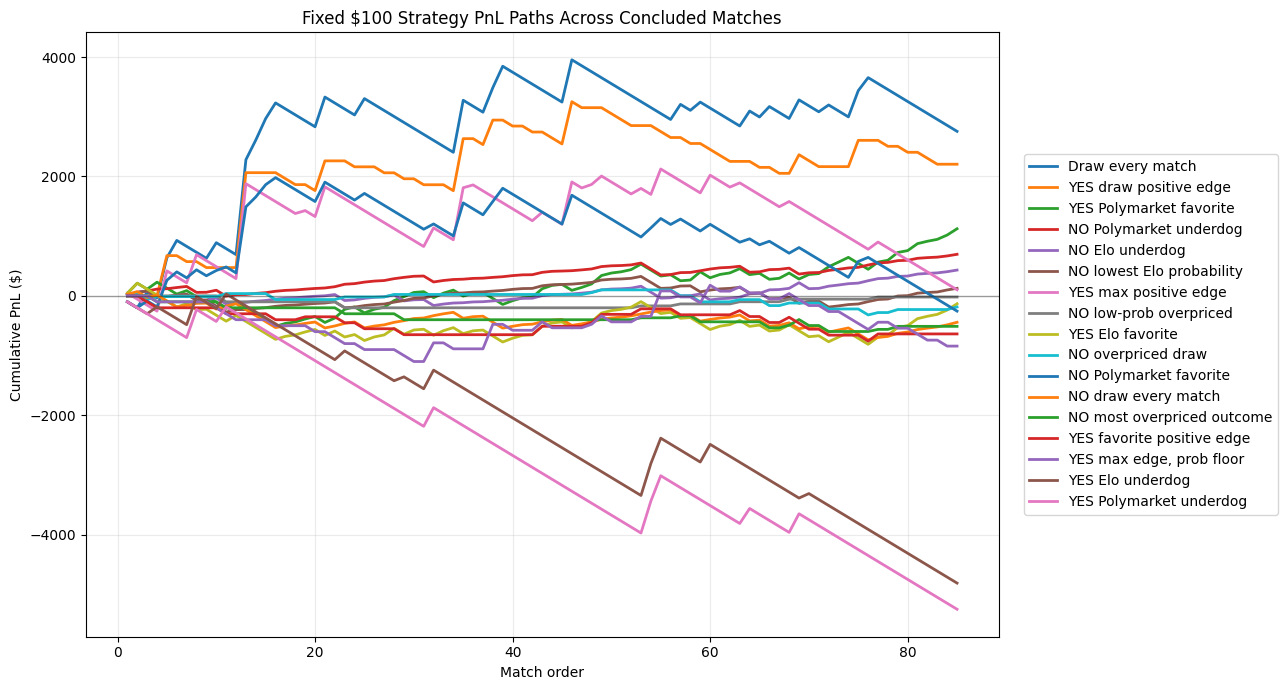

In [16]:
import matplotlib.pyplot as plt

pnl_paths = strategy_results.pivot_table(
    index="match_number",
    columns="strategy",
    values="cumulative_pnl",
    aggfunc="last",
).ffill().fillna(0)
export_derived_table(pnl_paths.reset_index(), "world_cup_pnl_paths.csv")

fig, ax = plt.subplots(figsize=(13, 7))
for strategy in strategy_summary.index:
    ax.plot(pnl_paths.index, pnl_paths[strategy], linewidth=2, label=strategy)

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.set_title(f"Fixed ${STAKE:,.0f} Strategy PnL Paths Across Concluded Matches")
ax.set_xlabel("Match order")
ax.set_ylabel("Cumulative PnL ($)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
strategy_results.sort_values(["match_number", "strategy"])[[
    "match_number",
    "event_title",
    "strategy",
    "selection",
    "actual_outcome",
    "bet_placed",
    "pnl",
    "cumulative_pnl",
]].head(80)

,match_number,event_title,strategy,selection,actual_outcome,bet_placed,pnl,cumulative_pnl
0,1,Mexico vs. South Africa,Draw every match,YES Draw,team1_win,True,-100.000000,-100.000000
935,1,Mexico vs. South Africa,NO Elo underdog,NO South Africa,team1_win,True,11.731844,11.731844
1275,1,Mexico vs. South Africa,NO Polymarket favorite,NO Mexico,team1_win,True,-100.000000,-100.000000
1360,1,Mexico vs. South Africa,NO Polymarket underdog,NO South Africa,team1_win,True,11.731844,11.731844
850,1,Mexico vs. South Africa,NO draw every match,NO Draw,team1_win,True,25.843325,25.843325
1105,1,Mexico vs. South Africa,NO low-prob overpriced,None,team1_win,False,0.000000,0.000000
1020,1,Mexico vs. South Africa,NO lowest Elo probability,NO South Africa,team1_win,True,11.731844,11.731844
765,1,Mexico vs. South Africa,NO most overpriced outcome,None,team1_win,False,0.000000,0.000000
1190,1,Mexico vs. South Africa,NO overpriced draw,None,team1_win,False,0.000000,0.000000
170,1,Mexico vs. South Africa,YES Elo favorite,YES Mexico,team1_win,True,44.109523,44.109523


## Notes / Things To Tune

- `BASE_DRAW_PROBABILITY_EQUAL_TEAMS` controls draw probability. The current default is `26%`; tune this with historical international data if you want calibrated draws.
- `HOME_ADVANTAGE_ELO` defaults to `0` because World Cup matches are mostly neutral-site, but co-host teams may deserve a positive adjustment.
- Elo TSV files refresh every run because they are cheap and change as new results arrive.
- Polymarket prices come only from the CLOB `prices-history` endpoint.
- `pre_match_yes_price` is the average implied YES price over `PRE_MATCH_PRICE_WINDOW_HOURS`. For completed matches, the window ends at kickoff. For upcoming matches, the window ends at current time.
- Completed Polymarket price-history windows are cached. Upcoming windows refresh each run because the current-time window changes.
- Only completed matches plus the next upcoming match day are included, so the notebook avoids downloading far-future fixture prices.
- The HTML export is written to `docs/data/football_elo_polymarket/world_cup_polymarket_elo_raw_table.csv` when `EXPORT_DERIVED_FOR_HTML = True`.

## Realized EV by Polymarket Odds Bucket

This groups every resolved 1x2 YES outcome quote into 10-cent Polymarket price buckets and calculates the realized net payout per `$1` staked.

For a YES bet at price `p`:

- If the outcome wins, net payout per `$1` staked is `1 / p - 1`.
- If the outcome loses, net payout per `$1` staked is `-1`.

So this is not model EV. It is the historical realized return for blindly buying every 1x2 outcome in each price bucket.

In [18]:
ODDS_BUCKET_EDGES = np.arange(0.0, 1.01, 0.1)
ODDS_BUCKET_LABELS = [f"{int(left * 100)}-{int(right * 100 - 0.1)}c" for left, right in zip(ODDS_BUCKET_EDGES[:-1], ODDS_BUCKET_EDGES[1:])]

outcome_price_rows = []
for row in raw_match_table.itertuples(index=False):
    if pd.isna(row.team1_goals) or pd.isna(row.team2_goals):
        continue

    if row.team1_goals > row.team2_goals:
        winning_outcome = "team1_win"
    elif row.team2_goals > row.team1_goals:
        winning_outcome = "team2_win"
    else:
        winning_outcome = "draw"

    for outcome, label, price in [
        ("team1_win", row.poly_team1, row.polymarket_team1_win_price),
        ("draw", "Draw", row.polymarket_draw_price),
        ("team2_win", row.poly_team2, row.polymarket_team2_win_price),
    ]:
        price = parse_float(price)
        if price is None or not (0 < price < 1):
            continue

        outcome_price_rows.append(
            {
                "event_start_time": row.event_start_time,
                "event_title": row.event_title,
                "outcome": outcome,
                "selection": label,
                "price": price,
                "won": outcome == winning_outcome,
                "net_payout_per_dollar": (1 / price - 1) if outcome == winning_outcome else -1,
            }
        )

odds_bucket_bets = pd.DataFrame(outcome_price_rows)
odds_bucket_bets["price_bucket"] = pd.cut(
    odds_bucket_bets["price"],
    bins=ODDS_BUCKET_EDGES,
    labels=ODDS_BUCKET_LABELS,
    include_lowest=True,
    right=False,
)

odds_bucket_summary = (
    odds_bucket_bets
    .groupby("price_bucket", observed=False)
    .agg(
        outcomes=("price", "size"),
        avg_price=("price", "mean"),
        wins=("won", "sum"),
        realized_win_rate=("won", "mean"),
        expected_win_rate_at_avg_price=("price", "mean"),
        avg_net_payout_per_dollar=("net_payout_per_dollar", "mean"),
        total_net_payout_per_dollar=("net_payout_per_dollar", "sum"),
    )
    .reset_index()
)

odds_bucket_summary["realized_edge_vs_price"] = odds_bucket_summary["realized_win_rate"] - odds_bucket_summary["expected_win_rate_at_avg_price"]
export_derived_table(odds_bucket_summary, "world_cup_odds_bucket_ev_summary.csv")
export_derived_table(odds_bucket_bets, "world_cup_odds_bucket_ev_details.csv")

odds_bucket_summary

[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_odds_bucket_ev_summary.csv
[export] /home/frederickpek/code/moirai/docs/data/football_elo_polymarket/world_cup_odds_bucket_ev_details.csv


,price_bucket,outcomes,avg_price,wins,realized_win_rate,expected_win_rate_at_avg_price,avg_net_payout_per_dollar,total_net_payout_per_dollar,realized_edge_vs_price
0,0-9c,33,0.061678,1,0.030303,0.061678,-0.487836,-16.098592,-0.031375
1,10-19c,59,0.152359,9,0.152542,0.152359,0.005886,0.347281,0.000183
2,20-29c,65,0.249243,14,0.215385,0.249243,-0.158505,-10.302828,-0.033858
3,30-39c,17,0.336216,3,0.176471,0.336216,-0.493792,-8.394471,-0.159745
4,40-49c,16,0.449583,11,0.687500,0.449583,0.552596,8.841535,0.237917
5,50-59c,17,0.555272,11,0.647059,0.555272,0.159785,2.716345,0.091787
6,60-69c,20,0.649986,14,0.700000,0.649986,0.077748,1.554956,0.050014
7,70-79c,12,0.741137,10,0.833333,0.741137,0.127588,1.531060,0.092197
8,80-89c,13,0.846946,10,0.769231,0.846946,-0.095840,-1.245923,-0.077715
9,90-99c,3,0.922266,2,0.666667,0.922266,-0.278865,-0.836595,-0.255600
